# FDC-Monitoring Knowledge Graph RAG Agent

## 개요

이 노트북은 **FAISS 벡터 검색**과 **networkx Knowledge Graph 탐색**을 결합한
**Hybrid Graph RAG** 파이프라인을 구현합니다.

### 그래프 스키마
```
(Equipment) -[HAS_ALARM]→  (Alarm)
  (Alarm)   -[HAS_SOP]→    (SOP)
   (SOP)    -[HAS_FAQ]→    (FAQ)
  (Alarm)   -[RELATED_VOC]→ (VOC)
```

### 주요 섹션
| # | 섹션 | 내용 |
|---|------|------|
| 0 | 의존성 설치 | pip install |
| 1 | 환경 변수 | .env 로드 + API 검증 |
| 2 | 매뉴얼 로드 | section chunk 생성 |
| 3 | FAISS Vectorstore | 벡터 검색 기반 |
| 4 | Master 데이터 | alarm/equipment CSV |
| 5 | LangGraph State | VOCState (Graph 필드 포함) |
| 6 | 노드 구현 | validate/retrieve/generate/citation |
| 7 | 그래프 조립 | 원본 app + app_graph_rag |
| 8 | 시각화 | Mermaid + networkx matplotlib |
| 9 | E2E 테스트 | 원본 RAG 경로 검증 |
| 12 | Graph RAG 확장 | KG 구축·graph_retrieve·hybrid 답변 |
| 12-B | 평가 지표 확장 | Graph Context Recall + Path Validity |
| 11 | 자동 평가 파이프라인 | RAGAS-Style 4지표 |


## 0. (필요 시) 의존성 설치

In [1]:
%pip install -q langchain langchain-openai langchain-community langchain-text-splitters
%pip install -q faiss-cpu python-dotenv langgraph

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## 1. 환경 변수 로드 + API 검증

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

env_path = PROJECT_ROOT / ".env"
loaded = load_dotenv(dotenv_path=env_path, override=True)
print(f".env 로드: {loaded}  (경로: {env_path})")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")

def _mask(k):
    if not k:
        return "(없음)"
    return k[:6] + "..." + k[-4:] if len(k) > 12 else "***"

print(f"OPENAI_API_KEY    : {_mask(OPENAI_API_KEY)}")
print(f"LANGSMITH_API_KEY : {_mask(LANGSMITH_API_KEY)}")

assert OPENAI_API_KEY, "OPENAI_API_KEY 가 .env 에 없습니다."

if LANGSMITH_API_KEY:
    os.environ["LANGCHAIN_TRACING_V2"] = "true"
    os.environ["LANGCHAIN_API_KEY"] = LANGSMITH_API_KEY
    os.environ.setdefault("LANGCHAIN_PROJECT", "fdc-langgraph-rag")
    print("LangSmith tracing 활성화 — project=fdc-langgraph-rag")
else:
    print("LangSmith 키 없음 — 트레이싱 비활성화")

.env 로드: True  (경로: C:\Users\User\Documents\Gen AI\Project\.env)
OPENAI_API_KEY    : sk-pro...WW8A
LANGSMITH_API_KEY : lsv2_p...f6fb
LangSmith tracing 활성화 — project=fdc-langgraph-rag


## 2. 매뉴얼 로드 + section chunk 생성

`agentic_rag.ipynb`와 동일한 로직을 재사용합니다.

In [3]:
MANUAL_DIR = PROJECT_ROOT / "data" / "manuals"
MANUAL_FILES = [
    "alarm_code_guide.md",
    "troubleshooting_guide.md",
    "operation_policy.md",
    "system_user_manual.md",
    "faq.md",
]

raw_manuals = {}
for fname in MANUAL_FILES:
    path = MANUAL_DIR / fname
    text = path.read_text(encoding="utf-8")
    raw_manuals[fname] = text
    print(f"  [{fname}] {len(text):,} chars")

  [alarm_code_guide.md] 12,230 chars
  [troubleshooting_guide.md] 12,245 chars
  [operation_policy.md] 5,980 chars
  [system_user_manual.md] 6,103 chars
  [faq.md] 4,603 chars


In [4]:
import re
from langchain_core.documents import Document

HEADER_RE = re.compile(
    r"^(?P<hashes>#{2,3})\s+(?P<sid>[A-Z]+-[A-Z0-9-]+)\s*\|\s*(?P<title>.+?)\s*$",
    re.MULTILINE,
)


def split_by_section(file_name: str, text: str):
    matches = list(HEADER_RE.finditer(text))
    if not matches:
        return []
    docs = []
    for i, m in enumerate(matches):
        start = m.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        body = text[start:end].rstrip()
        sid = m.group("sid")
        title = m.group("title").strip()
        citation = f"[{sid}] {title}"
        if len(citation) > 60:
            citation = citation[:57] + "..."
        docs.append(
            Document(
                page_content=body,
                metadata={
                    "file_name": file_name,
                    "section_id": sid,
                    "title": title,
                    "citation": citation,
                },
            )
        )
    return docs


chunks = []
for fname, text in raw_manuals.items():
    chunks.extend(split_by_section(fname, text))

print(f"총 chunk 수: {len(chunks)}")
from collections import Counter
for fname, n in Counter(c.metadata["file_name"] for c in chunks).items():
    print(f"  {fname}: {n}")

총 chunk 수: 91


  alarm_code_guide.md: 42
  troubleshooting_guide.md: 19
  operation_policy.md: 10
  system_user_manual.md: 10
  faq.md: 10


## 3. FAISS Vectorstore + Retriever

In [5]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS

embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectordb = FAISS.from_documents(chunks, embedding)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})

print(f"FAISS index 생성 완료 — 벡터 {vectordb.index.ntotal}개")

# Sanity check
_test = retriever.invoke("TEMP-H-001 챔버 과열 임계치")
print("Sanity check (TEMP-H-001 검색):")
for i, d in enumerate(_test[:2], 1):
    print(f"  [{i}] {d.metadata['citation']}")

FAISS index 생성 완료 — 벡터 91개


Sanity check (TEMP-H-001 검색):
  [1] [AC-TEMP-H-001] 챔버 과열 High (TEMP-H-001)
  [2] [AC-TEMP-C-001] 챔버 과열 Critical (TEMP-C-001)


## 4. Master 데이터 로드

`validate_entities` 노드에서 알람 코드와 설비 ID의 존재 여부를 검증하는 데 사용합니다.

In [6]:
import csv

ALARM_MASTER_PATH = PROJECT_ROOT / "data" / "db" / "alarm_code_master.csv"
EQUIP_MASTER_PATH = PROJECT_ROOT / "data" / "db" / "equipment_master.csv"

alarm_codes_valid: set[str] = set()
with open(ALARM_MASTER_PATH, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        alarm_codes_valid.add(row["alarm_code"].strip())

equipment_ids_valid: set[str] = set()
with open(EQUIP_MASTER_PATH, encoding="utf-8") as f:
    for row in csv.DictReader(f):
        equipment_ids_valid.add(row["equipment_id"].strip())

print(f"등록 알람 코드: {len(alarm_codes_valid)}개  (예: {sorted(alarm_codes_valid)[:4]})")
print(f"등록 설비 ID:   {len(equipment_ids_valid)}개  (예: {sorted(equipment_ids_valid)[:4]})")

등록 알람 코드: 42개  (예: ['CHEM-H-001', 'CHEM-W-001', 'COMM-H-001', 'COMM-M-001'])
등록 설비 ID:   30개  (예: ['CLN-WET-01', 'CLN-WET-02', 'CMP-POL-01', 'CMP-POL-02'])


## 5. LangGraph State 정의

`VOCState`는 그래프의 모든 노드가 공유하는 상태 객체입니다.  
각 노드는 `dict`를 반환해 해당 키만 업데이트하며, 나머지 키는 유지됩니다.

In [7]:
from typing import Optional, Literal
from typing_extensions import TypedDict


class VOCState(TypedDict):
    """그래프 전체를 흐르는 상태 스키마."""

    # ── 입력
    question: str

    # ── extract_entities 결과
    alarm_code: Optional[str]     # 추출된 알람 코드 (없으면 None)
    equipment_id: Optional[str]   # 추출된 설비 ID (없으면 None)
    intent: Optional[str]         # alarm_inquiry / sop_inquiry / policy_inquiry /
                                  # symptom / system_usage / out_of_scope / unknown

    # ── validate_entities 결과
    validation_status: Optional[Literal["valid_query", "invalid_entity", "need_clarification"]]
    validation_reason: Optional[str]

    # ── retrieve_context 결과
    retrieved_context: Optional[str]
    retrieved_section_ids: Optional[list]

    # ── generate_answer 결과
    answer: Optional[str]

    # ── validate_citation 결과
    cited_section_ids: Optional[list]
    citation_valid: Optional[bool]

    # ── 최종 출력
    final_answer: Optional[str]


print("VOCState 정의 완료")
print(f"필드: {list(VOCState.__annotations__.keys())}")

VOCState 정의 완료
필드: ['question', 'alarm_code', 'equipment_id', 'intent', 'validation_status', 'validation_reason', 'retrieved_context', 'retrieved_section_ids', 'answer', 'cited_section_ids', 'citation_valid', 'final_answer']


## 6. 노드 구현

### 6-1. `extract_entities` — 엔티티 추출

In [8]:
import json as _json

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

_EXTRACT_TMPL = """다음 질문에서 아래 정보를 JSON으로 추출하세요.

질문: {question}

추출 항목:
- alarm_code: 알람 코드 (예: TEMP-H-001, PRES-C-001). 언급 없으면 null
- equipment_id: 설비 ID (예: ETCH-DRY-01, THIN-CVD-02). 언급 없으면 null
- intent: 다음 중 하나
  * "alarm_inquiry"  — 알람 코드 의미·임계치 문의
  * "sop_inquiry"    — SOP·조치 절차 문의
  * "policy_inquiry" — 운영 정책·권한·escalation 문의
  * "system_usage"   — 시스템 사용법 문의
  * "symptom"        — 증상만 서술하고 코드 없음
  * "out_of_scope"   — FDC-Monitoring 범위 밖 질문
  * "unknown"        — 분류 불가

JSON 외 텍스트 없이 순수 JSON만 출력하세요.
예시: {{"alarm_code": "TEMP-H-001", "equipment_id": "ETCH-DRY-01", "intent": "alarm_inquiry"}}"""


def extract_entities(state: VOCState) -> dict:
    """질문에서 alarm_code, equipment_id, intent를 LLM으로 추출."""
    response = llm.invoke(_EXTRACT_TMPL.format(question=state["question"]))

    try:
        text = response.content.strip()
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
        extracted = _json.loads(text.strip())
    except Exception:
        extracted = {"alarm_code": None, "equipment_id": None, "intent": "unknown"}

    return {
        "alarm_code": extracted.get("alarm_code"),
        "equipment_id": extracted.get("equipment_id"),
        "intent": extracted.get("intent", "unknown"),
    }


# 단위 테스트
_sample = {"question": "ETCH-DRY-01 CH-A에서 TEMP-H-001 알람이 떴습니다. 의미가 뭔가요?"}
print("extract_entities 단위 테스트:")
print(extract_entities(_sample))

extract_entities 단위 테스트:


{'alarm_code': 'TEMP-H-001', 'equipment_id': 'ETCH-DRY-01', 'intent': 'alarm_inquiry'}


### 6-2. `validate_entities` — Master 데이터 대조 + routing 결정

In [9]:
def validate_entities(state: VOCState) -> dict:
    """alarm_code / equipment_id를 master CSV와 대조해 routing 상태를 결정."""

    alarm_code = state.get("alarm_code")
    equipment_id = state.get("equipment_id")
    intent = state.get("intent", "unknown")

    # 1) FDC-Monitoring 범위 밖
    if intent == "out_of_scope":
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                "요청하신 내용은 FDC-Monitoring 시스템의 운영 범위를 벗어납니다. "
                "관련 담당 팀에 문의해 주세요."
            ),
        }

    # 2) 알람 코드가 명시됐지만 master에 없음
    if alarm_code and alarm_code not in alarm_codes_valid:
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                f"알람 코드 '{alarm_code}'는 등록된 코드가 아닙니다. "
                "정확한 코드를 다시 확인해 주세요."
            ),
        }

    # 3) 설비 ID가 명시됐지만 master에 없음
    if equipment_id and equipment_id not in equipment_ids_valid:
        return {
            "validation_status": "invalid_entity",
            "validation_reason": (
                f"설비 ID '{equipment_id}'는 등록된 설비가 아닙니다. "
                "설비 ID를 다시 확인해 주세요."
            ),
        }

    # 4) 증상만 있고 alarm_code 미확인 → 명확화 필요
    if intent == "symptom" and not alarm_code:
        return {
            "validation_status": "need_clarification",
            "validation_reason": (
                "증상은 파악됐지만 알람 코드가 없어 정확한 원인을 특정하기 어렵습니다."
            ),
        }

    # 5) 의도가 alarm/sop 인데 코드·설비 모두 없음 → 명확화 필요
    if intent in ("alarm_inquiry", "sop_inquiry") and not alarm_code and not equipment_id:
        return {
            "validation_status": "need_clarification",
            "validation_reason": "알람 코드 또는 설비 ID 정보가 부족합니다.",
        }

    # 6) 분류 불가 → 명확화
    if intent == "unknown":
        return {
            "validation_status": "need_clarification",
            "validation_reason": "질문 의도를 파악하기 어렵습니다.",
        }

    # 7) 그 외 → 유효 쿼리
    return {
        "validation_status": "valid_query",
        "validation_reason": None,
    }


print("validate_entities 정의 완료")

validate_entities 정의 완료


### 6-3. `route_after_validation` — 조건부 엣지 라우팅 함수

LangGraph에서 조건부 분기는 **노드가 아닌 라우팅 함수**로 구현합니다.  
`add_conditional_edges(source_node, routing_fn, mapping)` 형태로 등록하면  
그래프가 `validate_entities` 이후 3방향으로 분기됩니다.

In [10]:
def route_after_validation(state: VOCState) -> str:
    """validate_entities 결과를 읽어 다음 노드 이름을 반환."""
    status = state.get("validation_status")
    if status == "invalid_entity":
        return "refusal_answer"
    elif status == "need_clarification":
        return "clarification_answer"
    else:
        return "retrieve_context"


print("route_after_validation 정의 완료")

route_after_validation 정의 완료


### 6-4. RAG 경로 노드: `retrieve_context` / `generate_answer` / `validate_citation`

In [11]:
def retrieve_context(state: VOCState) -> dict:
    """FAISS retriever로 관련 section chunk 검색."""

    alarm_code = state.get("alarm_code") or ""
    question = state["question"]
    search_query = f"{alarm_code} {question}".strip() if alarm_code else question

    docs = retriever.invoke(search_query)

    if not docs:
        return {
            "retrieved_context": "관련 매뉴얼 항목을 찾지 못했습니다.",
            "retrieved_section_ids": [],
        }

    section_ids = [d.metadata["section_id"] for d in docs]
    blocks = []
    for d in docs:
        block = (
            f"### {d.metadata['citation']}\n"
            f"(출처: {d.metadata['file_name']})\n\n"
            f"{d.page_content}"
        )
        blocks.append(block)

    return {
        "retrieved_context": "\n\n---\n\n".join(blocks),
        "retrieved_section_ids": section_ids,
    }

In [12]:
_GENERATE_TMPL = """너는 반도체 FDC-Monitoring 시스템의 VOC 응답 전문가다.
아래 매뉴얼 검색 결과를 근거로, 사용자 질문에 대한 구조화된 한국어 답변을 작성하라.

==== 검색된 매뉴얼 컨텍스트 ====
{context}

==== 사용자 질문 ====
{question}

==== 답변 형식 (6섹션) ====

**[1] 핵심 요약**
(1~2 문장으로 핵심만)

**[2] 알람 / 문제 정의**
(코드 의미, 발생 조건·임계치)

**[3] 원인 분석**
(주요 원인 bullet)

**[4] 조치 절차**
(단계별 번호 매기기)

**[5] 관련 정책 및 주의사항**
(SLA, 권한, escalation 등)

**[6] 인용 출처**
(참조한 section_id를 [SECTION-ID] 형식으로 나열)

중요:
- 컨텍스트에 없는 내용은 추측하지 말 것
- [6] 인용 출처는 검색 컨텍스트에 실제로 있는 section_id만 사용할 것
- 근거를 못 찾으면 [6]에 "해당 정보 없음"이라 명시"""


def generate_answer(state: VOCState) -> dict:
    """검색 근거 기반 6섹션 답변 생성."""
    context = state.get("retrieved_context", "컨텍스트 없음")
    question = state["question"]

    response = llm.invoke(_GENERATE_TMPL.format(context=context, question=question))
    return {"answer": response.content}

In [13]:
def validate_citation(state: VOCState) -> dict:
    """답변 속 [SECTION-ID] 인용이 검색 컨텍스트에 실제로 존재하는지 검증."""

    answer = state.get("answer", "")
    retrieved_ids = set(state.get("retrieved_section_ids") or [])

    # 답변에서 [SECTION-ID] 패턴 추출
    cited_ids = re.findall(r"\[([A-Z]+-[A-Z0-9-]+)\]", answer)
    cited_ids = list(dict.fromkeys(cited_ids))  # 중복 제거, 순서 유지

    invalid_citations = [sid for sid in cited_ids if sid not in retrieved_ids]
    citation_valid = len(invalid_citations) == 0

    if citation_valid:
        final_answer = answer
    else:
        warning = (
            f"\n\n---\n> **[인용 검증 경고]** "
            f"다음 section_id는 검색 컨텍스트에서 확인되지 않았습니다: "
            f"{', '.join(invalid_citations)}"
        )
        final_answer = answer + warning

    return {
        "cited_section_ids": cited_ids,
        "citation_valid": citation_valid,
        "final_answer": final_answer,
    }


print("RAG 경로 노드 3종 정의 완료")

RAG 경로 노드 3종 정의 완료


### 6-5. 종단 노드: `refusal_answer` / `clarification_answer`

In [14]:
def refusal_answer(state: VOCState) -> dict:
    """존재하지 않는 코드·설비 또는 범위 밖 요청에 대한 정중한 거절 생성."""

    reason = state.get("validation_reason", "처리할 수 없는 요청입니다.")
    alarm_code = state.get("alarm_code")
    equipment_id = state.get("equipment_id")

    prompt = f"""다음 상황에서 정중하고 명확한 거절 응답을 한국어로 작성하라.

상황: {reason}
언급된 알람 코드: {alarm_code or '없음'}
언급된 설비 ID:   {equipment_id or '없음'}
원래 질문: {state['question']}

안내 사항:
- 어떤 문제인지 구체적으로 설명하라
- 사용자가 다음에 무엇을 해야 하는지 안내하라
- 2~3 문장으로 간결하게"""

    response = llm.invoke(prompt)
    return {
        "final_answer": response.content,
        "citation_valid": None,
    }


def clarification_answer(state: VOCState) -> dict:
    """부족한 정보를 되묻는 명확화 요청 응답 생성."""

    reason = state.get("validation_reason", "정보가 부족합니다.")
    intent = state.get("intent", "unknown")

    prompt = f"""다음 상황에서 사용자에게 추가 정보를 요청하는 응답을 한국어로 작성하라.

상황: {reason}
파악된 의도: {intent}
원래 질문: {state['question']}

요청할 정보 (해당되는 것만):
- 설비 ID (예: ETCH-DRY-01, THIN-CVD-02)
- 알람 코드 (예: TEMP-H-001, PRES-C-001)
- 증상 발생 시점·빈도
- 챔버 번호 (해당 시)

친근하고 도움이 되는 톤으로, 3~4 문장 이내로 작성하라."""

    response = llm.invoke(prompt)
    return {
        "final_answer": response.content,
        "citation_valid": None,
    }


print("refusal_answer / clarification_answer 정의 완료")

refusal_answer / clarification_answer 정의 완료


## 7. 그래프 조립 + 컴파일

`StateGraph`에 노드를 등록하고 엣지를 연결합니다.  
`add_conditional_edges`가 LangGraph 조건부 분기의 핵심입니다.

In [15]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(VOCState)

# ── 노드 등록
workflow.add_node("extract_entities", extract_entities)
workflow.add_node("validate_entities", validate_entities)
workflow.add_node("retrieve_context", retrieve_context)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("validate_citation", validate_citation)
workflow.add_node("refusal_answer", refusal_answer)
workflow.add_node("clarification_answer", clarification_answer)

# ── 직선 엣지
workflow.add_edge(START, "extract_entities")
workflow.add_edge("extract_entities", "validate_entities")
workflow.add_edge("retrieve_context", "generate_answer")
workflow.add_edge("generate_answer", "validate_citation")
workflow.add_edge("validate_citation", END)
workflow.add_edge("refusal_answer", END)
workflow.add_edge("clarification_answer", END)

# ── 조건부 분기: validate_entities → route_after_validation → 3방향
workflow.add_conditional_edges(
    "validate_entities",          # 분기 시작 노드
    route_after_validation,        # 라우팅 함수 (상태를 읽어 노드 이름 반환)
    {
        "retrieve_context":     "retrieve_context",
        "refusal_answer":       "refusal_answer",
        "clarification_answer": "clarification_answer",
    }
)

# ── 컴파일
app = workflow.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


## 8. 그래프 시각화 (Mermaid)

LangGraph는 그래프 구조를 Mermaid 다이어그램으로 자동 변환합니다.

In [16]:
# Mermaid 소스 출력
mermaid_src = app.get_graph().draw_mermaid()
print("=== Mermaid Source ===")
print(mermaid_src)

=== Mermaid Source ===
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_entities(extract_entities)
	validate_entities(validate_entities)
	retrieve_context(retrieve_context)
	generate_answer(generate_answer)
	validate_citation(validate_citation)
	refusal_answer(refusal_answer)
	clarification_answer(clarification_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_entities;
	extract_entities --> validate_entities;
	generate_answer --> validate_citation;
	retrieve_context --> generate_answer;
	validate_entities -.-> clarification_answer;
	validate_entities -.-> refusal_answer;
	validate_entities -.-> retrieve_context;
	clarification_answer --> __end__;
	refusal_answer --> __end__;
	validate_citation --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



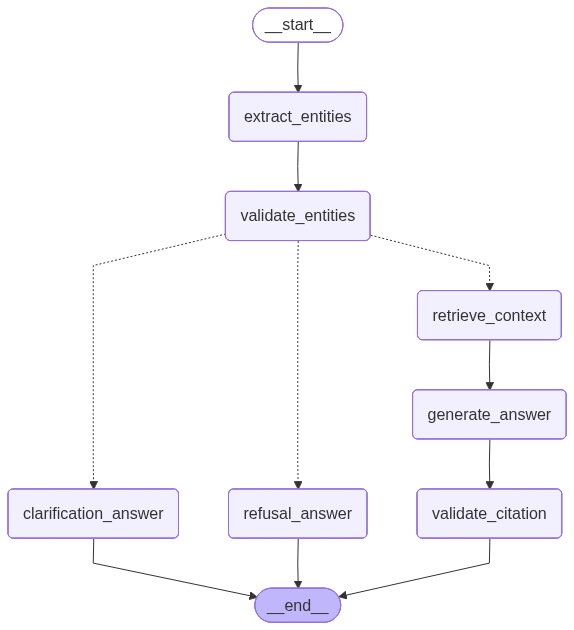

In [17]:
# PNG 렌더링 (mermaid.ink API 사용 — 인터넷 필요)
from IPython.display import Image, display

try:
    img_bytes = app.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"PNG 렌더링 실패: {e}")
    print("위 Mermaid 소스를 https://mermaid.live 에 붙여넣어 시각화하세요.")

### 수동 Mermaid 다이어그램 (PNG 실패 시 참조)

```mermaid
flowchart TD
    START([START]) --> EX[extract_entities]
    EX --> VA[validate_entities]
    VA -->|invalid_entity| RA[refusal_answer]
    VA -->|need_clarification| CA[clarification_answer]
    VA -->|valid_query| RC[retrieve_context]
    RC --> GA[generate_answer]
    GA --> VC[validate_citation]
    VC --> END_V([END])
    RA --> END_R([END])
    CA --> END_C([END])

    style RA fill:#ffcccc
    style CA fill:#fff3cc
    style VC fill:#ccffcc
    style RC fill:#cce5ff
    style GA fill:#cce5ff
```

## 9. End-to-End 테스트

### 4가지 경로 커버리지

| 테스트 | 기대 경로 | VOC |
|---|---|---|
| Easy (valid) | valid_query → RAG → validate_citation | VOC-2026-0001 |
| Trap (invalid code) | invalid_entity → refusal | VOC-2026-0027 |
| Symptom (no code) | need_clarification → clarification | VOC-2026-0017 |
| Medium SOP | valid_query → RAG → validate_citation | VOC-2026-0009 |

In [18]:
import json as _json_voc

VOC_PATH = PROJECT_ROOT / "data" / "voc" / "voc_samples.json"
all_vocs = _json_voc.loads(VOC_PATH.read_text(encoding="utf-8"))["vocs"]
voc_by_id = {v["voc_id"]: v for v in all_vocs}

print(f"VOC 전체 {len(all_vocs)}건 로드")


def run_graph(voc_id: str, verbose: bool = True) -> VOCState:
    """단일 VOC를 그래프에 실행하고 최종 상태를 반환."""
    voc = voc_by_id[voc_id]
    question = voc["content"]

    SEP = "=" * 80
    if verbose:
        print(SEP)
        print(f"[{voc_id}] difficulty={voc['difficulty']} | category={voc['category']}")
        print(f"Q: {question}")
        print("-" * 80)

    # 그래프 실행 (stream으로 노드별 상태 덤프)
    final_state = None
    for step in app.stream({"question": question}, stream_mode="updates"):
        for node_name, update in step.items():
            if verbose:
                # 각 노드가 업데이트한 키만 보여주기
                keys = list(update.keys())
                print(f"  ▶ [{node_name}] 업데이트: {keys}")
                if "validation_status" in update:
                    print(f"       validation_status = {update['validation_status']}")
                    if update.get("validation_reason"):
                        print(f"       reason = {update['validation_reason']}")
                if "retrieved_section_ids" in update:
                    print(f"       retrieved = {update['retrieved_section_ids']}")
                if "cited_section_ids" in update:
                    print(f"       cited    = {update['cited_section_ids']}")
                    print(f"       valid    = {update.get('citation_valid')}")

    # 전체 최종 상태 가져오기
    final_state = app.invoke({"question": question})

    if verbose:
        print("-" * 80)
        print("[최종 답변]")
        for line in (final_state.get("final_answer") or "").splitlines():
            print(f"  {line}")
        print(SEP)
        print()

    return final_state

VOC 전체 115건 로드


### 테스트 1 — Easy (유효한 알람 코드 + 설비 → RAG 경로)

In [19]:
state1 = run_graph("VOC-2026-0001")  # ETCH-DRY-01 / TEMP-H-001

[VOC-2026-0001] difficulty=easy | category=알람 코드 의미 문의
Q: ETCH-DRY-01 CH-A에서 오늘 오후 TEMP-H-001 알람이 떴습니다. 이 알람 코드가 정확히 무엇을 의미하나요?
--------------------------------------------------------------------------------


  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = valid_query
  ▶ [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
       retrieved = ['FAQ-003', 'SM-ALM-001', 'AC-TEMP-M-001', 'AC-TEMP-H-001']


  ▶ [generate_answer] 업데이트: ['answer']
  ▶ [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
       cited    = ['SOP-TEMP-001', 'AC-TEMP-H-001']
       valid    = False


--------------------------------------------------------------------------------
[최종 답변]
  **[1] 핵심 요약**  
  TEMP-H-001 알람은 챔버 온도가 설정값보다 20°C 이상 초과했음을 의미하며, 자동으로 hold 상태로 전환됩니다.
  
  **[2] 알람 / 문제 정의**  
  - **코드 의미**: 챔버 과열 High (TEMP-H-001)  
  - **발생 조건·임계치**: 챔버 온도가 recipe setpoint + 20°C를 초과할 경우 (예: setpoint가 300°C일 때 320°C 초과)
  
  **[3] 원인 분석**  
  - 가스 유량 부족으로 인한 발열 누적  
  - 냉각수 유량 저하  
  - 히터 over-shoot  
  
  **[4] 조치 절차**  
  1. 챔버 온도를 확인하고, 현재 온도가 설정값을 초과하는지 점검합니다.  
  2. 가스 유량과 냉각수 유량을 점검하여 부족한 부분이 있는지 확인합니다.  
  3. 히터의 작동 상태를 점검하고, 필요 시 조정합니다.  
  4. 조치 후에도 문제가 지속되면 [SOP-TEMP-001] 절차를 따릅니다.  
  
  **[5] 관련 정책 및 주의사항**  
  - SLA: 알람 발생 시 즉시 확인하고 조치해야 합니다.  
  - 권한: 조치 절차는 해당 설비의 운영자 또는 기술자가 수행해야 합니다.  
  - Escalation: 문제가 지속될 경우, 관련 SOP에 따라 escalation 절차를 따릅니다.  
  
  **[6] 인용 출처**  
  [AC-TEMP-H-001]
  
  ---
  > **[인용 검증 경고]** 다음 section_id는 검색 컨텍스트에서 확인되지 않았습니다: SOP-TEMP-001



### 테스트 2 — Trap (존재하지 않는 알람 코드 → refusal 경로)

In [20]:
state2 = run_graph("VOC-2026-0027")  # TEMP-Z-999 (등록되지 않은 코드)

[VOC-2026-0027] difficulty=trap | category=알람 코드 의미 문의
Q: 오늘 오전 대시보드에 TEMP-Z-999라는 알람이 떴습니다. 무엇을 의미하는 알람인가요? 어떻게 조치해야 하나요?
--------------------------------------------------------------------------------


  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = invalid_entity
       reason = 알람 코드 'TEMP-Z-999'는 등록된 코드가 아닙니다. 정확한 코드를 다시 확인해 주세요.


  ▶ [refusal_answer] 업데이트: ['final_answer', 'citation_valid']


--------------------------------------------------------------------------------
[최종 답변]
  안녕하세요. 문의하신 알람 코드 'TEMP-Z-999'는 등록된 코드가 아니므로, 해당 알람의 의미를 확인할 수 없습니다. 정확한 알람 코드를 다시 확인하시고, 필요하신 경우 관련 부서에 문의해 주시기 바랍니다. 감사합니다.



### 테스트 3 — 증상만 있고 코드 없음 → clarification 경로

In [21]:
state3 = run_graph("VOC-2026-0017")  # 챔버 과열 증상 (코드 미명시)

[VOC-2026-0017] difficulty=hard | category=조치 방법 문의
Q: ETCH-DRY-02 CH-A에서 공정 중 챔버 온도가 setpoint보다 점점 높아지는 현상이 어제부터 반복되고 있습니다. 알람이 뜬 적도 있고 안 뜬 적도 있습니다. 어떤 점부터 확인해야 하나요?
--------------------------------------------------------------------------------


  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = need_clarification
       reason = 증상은 파악됐지만 알람 코드가 없어 정확한 원인을 특정하기 어렵습니다.


  ▶ [clarification_answer] 업데이트: ['final_answer', 'citation_valid']


--------------------------------------------------------------------------------
[최종 답변]
  안녕하세요! 챔버 온도가 setpoint보다 높아지는 현상에 대해 도움을 드리고 싶습니다. 정확한 원인을 파악하기 위해 몇 가지 추가 정보를 요청드립니다. 사용 중인 설비 ID와 알람 코드, 증상이 발생한 시점과 빈도, 그리고 챔버 번호를 알려주시면 더욱 정확한 진단이 가능할 것 같습니다. 감사합니다!



### 테스트 4 — Medium SOP (COMM-H-001 EAP 통신 단절 → RAG + validate_citation)

In [22]:
state4 = run_graph("VOC-2026-0013")  # COMM-H-001 EAP 통신 단절

[VOC-2026-0013] difficulty=medium | category=조치 방법 문의
Q: PHOTO-SCN-02에서 COMM-H-001 알람. 호스트 통신이 1분 이상 단절됐습니다. EAP 재시작은 제가 할 수 있나요?
--------------------------------------------------------------------------------


  ▶ [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  ▶ [validate_entities] 업데이트: ['validation_status', 'validation_reason']
       validation_status = valid_query
  ▶ [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
       retrieved = ['SOP-COMM-001', 'AC-COMM-H-001', 'FAQ-007', 'AC-COMM-M-001']


  ▶ [generate_answer] 업데이트: ['answer']
  ▶ [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
       cited    = ['AC-COMM-H-001', 'SOP-COMM-001']
       valid    = True


--------------------------------------------------------------------------------
[최종 답변]
  **[1] 핵심 요약**  
  PHOTO-SCN-02에서 COMM-H-001 알람이 발생하여 호스트 통신이 1분 이상 단절되었습니다. EAP 재시작은 EQ_ENG 권한이 필요합니다.
  
  **[2] 알람 / 문제 정의**  
  - **알람 코드**: COMM-H-001  
  - **의미**: 설비 EAP와 호스트(MES/FDC) 간 link 단절  
  - **발생 조건**: EAP-호스트 link가 60초 이상 단절된 경우
  
  **[3] 원인 분석**  
  - 네트워크 스위치 이슈  
  - EAP 프로세스 hang  
  
  **[4] 조치 절차**  
  1. EAP 프로세스 상태 확인  
  2. 네트워크 연결 확인 (ping 테스트)  
  3. EAP 재시작 (EQ_ENG 권한 필요)  
  4. 수동 운영 모드 전환 (30분 이상 지연 시 PROC_ENG 승인 필요)  
  5. 통신 복구 후 이력 동기화  
  
  **[5] 관련 정책 및 주의사항**  
  - EAP 재시작은 EQ_ENG 권한이 있어야 가능합니다.  
  - 수동 운영 모드는 최대 4시간 이내로 제한됩니다.  
  - 2단계에서 네트워크 자체 이상이 발견되면 IT/CIM팀에 호출해야 합니다.
  
  **[6] 인용 출처**  
  [AC-COMM-H-001], [SOP-COMM-001]



## 10. 상태 인스펙션 — 노드별 중간값 확인

LangGraph의 장점: `stream_mode="values"`로 각 노드 실행 후 전체 상태를 snapshot처럼 볼 수 있습니다.

In [23]:
# RAG 경로의 각 노드 실행 후 상태 스냅샷
voc_inspect = voc_by_id["VOC-2026-0009"]  # TEMP-H-001 SOP 문의

print(f"Q: {voc_inspect['content']}")
print()

snapshots = []
for snapshot in app.stream(
    {"question": voc_inspect["content"]},
    stream_mode="values",
):
    snapshots.append(dict(snapshot))

# 각 스냅샷에서 핵심 필드만 출력
SHOW_KEYS = [
    "alarm_code", "equipment_id", "intent",
    "validation_status", "retrieved_section_ids",
    "cited_section_ids", "citation_valid",
]

for i, snap in enumerate(snapshots):
    print(f"--- Snapshot {i} ---")
    for k in SHOW_KEYS:
        if k in snap and snap[k] is not None:
            print(f"  {k}: {snap[k]}")
    print()

Q: THIN-CVD-02 CH-B에서 TEMP-H-001 발생. 현재 챔버 온도 335°C, recipe setpoint 310°C, recipe는 R-CVD-15입니다. 어떤 순서로 점검해야 하나요?



--- Snapshot 0 ---

--- Snapshot 1 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry

--- Snapshot 2 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query

--- Snapshot 3 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001', 'AC-TEMP-M-001']

--- Snapshot 4 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001', 'AC-TEMP-M-001']

--- Snapshot 5 ---
  alarm_code: TEMP-H-001
  equipment_id: THIN-CVD-02
  intent: sop_inquiry
  validation_status: valid_query
  retrieved_section_ids: ['AC-TEMP-C-001', 'AC-TEMP-H-001', 'SOP-TEMP-001', 'AC-TEMP-M-001']
  cited_section_ids: ['AC-TEMP-H-001', 'SOP-TEMP-001']
  citation_valid: True



## 12. Graph RAG 확장 — Knowledge Graph 기반 Hybrid Retrieval

기존 Vector-only RAG 구조를 **점진적으로** Knowledge Graph 기반으로 확장합니다.

```
기존: validate_entities → retrieve_context → generate_answer → validate_citation
확장: validate_entities → graph_retrieve → retrieve_context
                                              └─ (vector) ┐
                               generate_answer_hybrid ◄──┘
                                    └─ (graph_context) ┘
                                        validate_citation
```

### Knowledge Graph 스키마

```
(EQP) -[:HAS_ALARM]→ (ALARM) -[:HAS_SOP]→ (SOP) -[:HAS_FAQ]→ (FAQ)
                             -[:RELATED_VOC]→ (VOC)
```

| 노드 | 색상 | 데이터 소스 |
|---|---|---|
| Equipment | 파랑 | `equipment_master.csv` |
| Alarm | 빨강 | `alarm_code_master.csv` |
| SOP | 초록 | `troubleshooting_guide.md` 섹션 |
| FAQ | 주황 | `faq.md` 섹션 |
| VOC | 보라 | `voc_samples.json` |


In [24]:
# VOCState 확장 — graph_retrieve 결과를 담을 4개 필드 추가
# 기존 노드는 그대로 동작 (TypedDict는 추가 키를 무시)
class VOCState(TypedDict):
    """Graph RAG 확장 상태 스키마."""
    # ── 기존 필드 (변경 없음)
    question:              str
    alarm_code:            Optional[str]
    equipment_id:          Optional[str]
    intent:                Optional[str]
    validation_status:     Optional[Literal["valid_query", "invalid_entity", "need_clarification"]]
    validation_reason:     Optional[str]
    retrieved_context:     Optional[str]
    retrieved_section_ids: Optional[list]
    answer:                Optional[str]
    cited_section_ids:     Optional[list]
    citation_valid:        Optional[bool]
    final_answer:          Optional[str]
    # ── Graph RAG 확장 필드
    graph_entities:        Optional[list]   # 탐색된 노드 목록
    graph_relations:       Optional[list]   # 탐색된 엣지 목록
    graph_context:         Optional[str]    # 그래프 탐색 요약 텍스트
    graph_paths:           Optional[list]   # 탐색 경로 문자열 목록

print("VOCState 확장 완료")
print("  추가 필드:", ["graph_entities", "graph_relations", "graph_context", "graph_paths"])


VOCState 확장 완료
  추가 필드: ['graph_entities', 'graph_relations', 'graph_context', 'graph_paths']


In [25]:
import networkx as nx
import csv as _csv_kg
import json as _json_kg

KG = nx.DiGraph()

# ─── 1. Equipment 노드 (equipment_master.csv) ────────────────────────────────
with open(EQUIP_MASTER_PATH, encoding="utf-8") as _f:
    for row in _csv_kg.DictReader(_f):
        eid = row["equipment_id"].strip()
        KG.add_node(eid,
            node_type  = "equipment",
            eq_type    = row["type"].strip(),
            process    = row["process"].strip(),
            full_name  = row["full_name"].strip(),
            location   = row["location"].strip(),
            status     = row["status"].strip(),
        )

# ─── 2. Alarm 노드 (alarm_code_master.csv) ───────────────────────────────────
_alarm_rows = []
with open(ALARM_MASTER_PATH, encoding="utf-8") as _f:
    for row in _csv_kg.DictReader(_f):
        code = row["alarm_code"].strip()
        KG.add_node(code,
            node_type        = "alarm",
            name             = row["name"].strip(),
            category         = row["category"].strip(),
            severity         = row["severity"].strip(),
            threshold_text   = row["threshold_text"].strip(),
            typical_causes   = row["typical_causes"].strip(),
            applicable_types = [t.strip() for t in row["applicable_eq_types"].split("|") if t.strip()],
            section_id       = row["section_id"].strip(),
            related_sop_id   = row["related_sop_id"].strip(),
        )
        _alarm_rows.append(row)

# ─── 3. SOP 노드 (alarm_code_master.csv에서 unique SOP 추출) ──────────────────
_SOP_META = {
    "SOP-TEMP-001" : "챔버 과열 대응 절차",
    "SOP-TEMP-002" : "챔버 온도 불균형 대응",
    "SOP-PRES-001" : "챔버 압력 이상 대응",
    "SOP-FLOW-001" : "가스 Flow 이상 대응",
    "SOP-RF-001"   : "RF Critical 긴급 대응",
    "SOP-RF-002"   : "RF Matching 불량 대응",
    "SOP-VAC-001"  : "진공 누설 대응 절차",
    "SOP-VAC-002"  : "진공도 미달 모니터링",
    "SOP-GAS-001"  : "Toxic Gas 긴급 대응",
    "SOP-GAS-002"  : "가스 라인 누설 대응",
    "SOP-HV-001"   : "고전압 이상 대응",
    "SOP-DOSE-001" : "Dose 이상 대응 절차",
    "SOP-CHEM-001" : "Chemical 이상 대응",
    "SOP-COMM-001" : "EAP 통신 단절 대응",
    "SOP-REC-001"  : "Recipe 다운로드 실패 대응",
    "SOP-MECH-001" : "기계 장치 이상 대응",
    "SOP-MECH-002" : "기계 장치 모니터링",
    "SOP-ESC-001"  : "일반 Escalation 절차",
    "SOP-ESC-002"  : "야간/비상 Escalation",
}
for sop_id, title in _SOP_META.items():
    KG.add_node(sop_id,
        node_type  = "sop",
        title      = title,
        file       = "troubleshooting_guide.md",
        section_id = sop_id,
    )

# ─── 4. FAQ 노드 ──────────────────────────────────────────────────────────────
_FAQ_META = {
    "FAQ-001": "알람 발생 시 첫 번째 조치",
    "FAQ-002": "Trend Chart 데이터 없음 원인",
    "FAQ-003": "Critical 알람 manual vent 금지",
    "FAQ-004": "가스 실린더 교체 절차",
    "FAQ-005": "VOC SLA 및 처리 기한",
    "FAQ-006": "임계치 변경 신청 절차",
    "FAQ-007": "진공 O-ring 교체 시기",
    "FAQ-008": "Recipe 버전 불일치 의미",
    "FAQ-009": "데이터 보존 기간",
    "FAQ-010": "야간 비상 연락 체계",
}
for faq_id, title in _FAQ_META.items():
    KG.add_node(faq_id,
        node_type  = "faq",
        title      = title,
        file       = "faq.md",
        section_id = faq_id,
    )

# ─── 5. VOC 노드 (voc_samples.json) ──────────────────────────────────────────
_VOC_PATH = PROJECT_ROOT / "data" / "voc" / "voc_samples.json"
with open(_VOC_PATH, encoding="utf-8") as _f:
    _vocs = _json_kg.load(_f)["vocs"]
for voc in _vocs:
    vid = voc["voc_id"]
    KG.add_node(vid,
        node_type    = "voc",
        title        = voc.get("title", ""),
        category     = voc.get("category", ""),
        alarm_code   = voc.get("alarm_code", ""),
        equipment_id = voc.get("equipment_id", ""),
        priority     = voc.get("priority", ""),
    )

# ─── 6. Equipment → Alarm 엣지 (applicable_eq_types 기반) ────────────────────
for row in _alarm_rows:
    code = row["alarm_code"].strip()
    applicable = [t.strip() for t in row["applicable_eq_types"].split("|") if t.strip()]
    for node_id, node_data in KG.nodes(data=True):
        if node_data.get("node_type") == "equipment":
            if node_data.get("eq_type") in applicable:
                KG.add_edge(node_id, code, relation="HAS_ALARM")

# ─── 7. Alarm → SOP 엣지 ─────────────────────────────────────────────────────
for row in _alarm_rows:
    code   = row["alarm_code"].strip()
    sop_id = row["related_sop_id"].strip()
    if sop_id and sop_id in KG.nodes:
        KG.add_edge(code, sop_id, relation="HAS_SOP")

# ─── 8. SOP → FAQ 엣지 (도메인 지식 기반) ────────────────────────────────────
_SOP_FAQ_EDGES = [
    ("SOP-TEMP-001", "FAQ-001"),
    ("SOP-PRES-001", "FAQ-003"),
    ("SOP-COMM-001", "FAQ-002"),
    ("SOP-COMM-001", "FAQ-005"),
    ("SOP-GAS-002",  "FAQ-004"),
    ("SOP-VAC-001",  "FAQ-007"),
    ("SOP-REC-001",  "FAQ-008"),
    ("SOP-ESC-002",  "FAQ-010"),
]
for sop, faq in _SOP_FAQ_EDGES:
    if sop in KG.nodes and faq in KG.nodes:
        KG.add_edge(sop, faq, relation="HAS_FAQ")

# GAS-W-001은 SOP 없이 FAQ-004 직접 연결 (예외 케이스)
if "GAS-W-001" in KG.nodes and "FAQ-004" in KG.nodes:
    KG.add_edge("GAS-W-001", "FAQ-004", relation="HAS_FAQ")

# ─── 9. Alarm → VOC 엣지 (voc.alarm_code 기반) ───────────────────────────────
for voc in _vocs:
    alarm = voc.get("alarm_code", "").strip()
    vid   = voc["voc_id"]
    if alarm and alarm in KG.nodes:
        KG.add_edge(alarm, vid, relation="RELATED_VOC")

# ─── 통계 출력 ────────────────────────────────────────────────────────────────
from collections import Counter as _KGCounter
type_counts = _KGCounter(d.get("node_type", "?") for _, d in KG.nodes(data=True))
rel_counts  = _KGCounter(d.get("relation", "?") for _, _, d in KG.edges(data=True))

print(f"Knowledge Graph 구축 완료")
print(f"  노드: {KG.number_of_nodes():,}개  {dict(type_counts)}")
print(f"  엣지: {KG.number_of_edges():,}개  {dict(rel_counts)}")


Knowledge Graph 구축 완료
  노드: 216개  {'equipment': 30, 'alarm': 42, 'sop': 19, 'faq': 10, 'voc': 115}
  엣지: 568개  {'HAS_ALARM': 473, 'HAS_SOP': 35, 'RELATED_VOC': 51, 'HAS_FAQ': 9}


C:\Users\User\AppData\Local\Temp\ipykernel_18816\3123758382.py:93: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_18816\3123758382.py:93: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52308 (\N{HANGUL SYLLABLE CAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48260 (\N{HANGUL SYLLABLE BEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing f

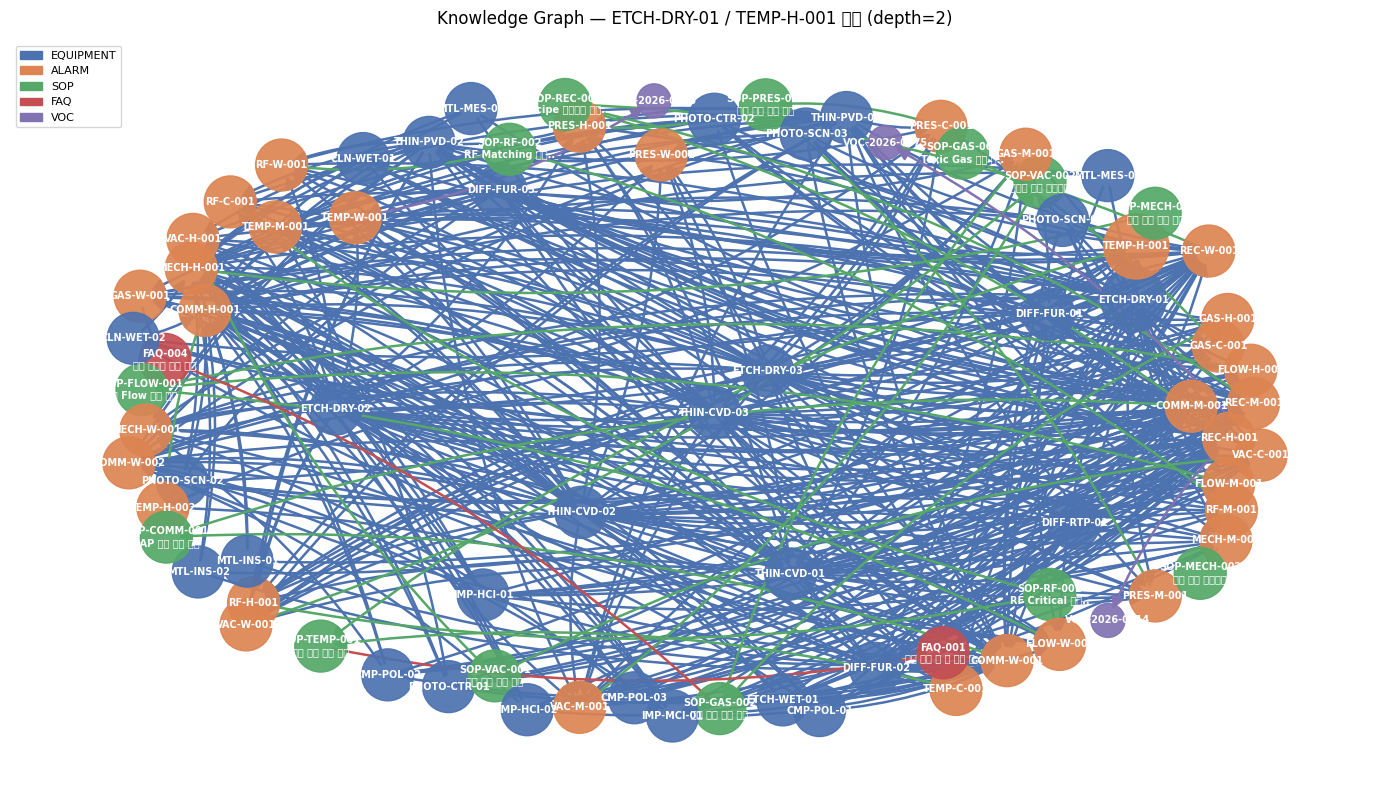

  서브그래프: 노드 82개, 엣지 468개


C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48143 (\N{HANGUL SYLLABLE MIC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\envs\gen_ai\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


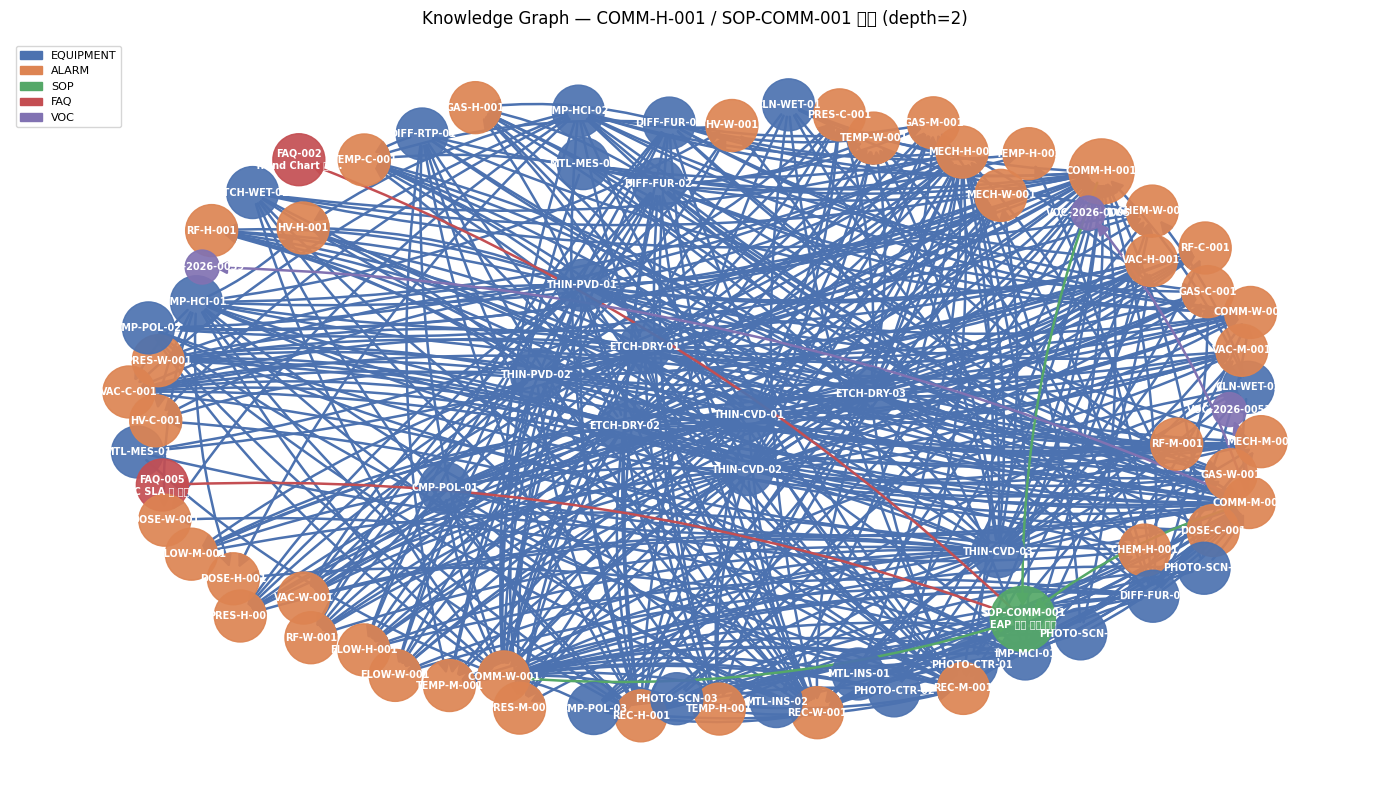

  서브그래프: 노드 78개, 엣지 481개

[ TEMP-H-001 연결 경로 예시 ]
ETCH-DRY-01 → TEMP-C-001 → SOP-TEMP-001
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0001: TEMP-H-001 알람 의미가 궁금합니다
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0009: TEMP-H-001 떴는데 조치 방법 알려주세요
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0054: TEMP-H-001 발생 — 원인이 궁금합니다


In [26]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

matplotlib.rcParams["font.family"] = "DejaVu Sans"

_NODE_COLOR = {
    "equipment" : "#4C72B0",   # 파랑
    "alarm"     : "#DD8452",   # 주황
    "sop"       : "#55A868",   # 초록
    "faq"       : "#C44E52",   # 빨강
    "voc"       : "#8172B2",   # 보라
}

def draw_subgraph(center_nodes: list, depth: int = 2, title: str = "", figsize=(14, 8)):
    """중심 노드에서 depth 홉 이내 서브그래프를 시각화."""
    sub_nodes = set(center_nodes)
    frontier  = set(center_nodes)
    for _ in range(depth):
        next_frontier = set()
        for n in frontier:
            next_frontier.update(KG.successors(n))
            next_frontier.update(KG.predecessors(n))
        sub_nodes |= next_frontier
        frontier = next_frontier

    # VOC 노드는 최대 3개로 제한 (가독성)
    voc_nodes = [n for n in sub_nodes if KG.nodes[n].get("node_type") == "voc"]
    sub_nodes -= set(voc_nodes[3:])

    SG = KG.subgraph(sub_nodes).copy()

    fig, ax = plt.subplots(figsize=figsize)

    # 레이아웃 — 계층 구조 강조
    try:
        pos = nx.nx_agraph.graphviz_layout(SG, prog="dot")
    except Exception:
        pos = nx.spring_layout(SG, k=2.5, seed=42)

    # 노드 색상 / 크기
    node_colors = [_NODE_COLOR.get(SG.nodes[n].get("node_type", ""), "#aaa") for n in SG.nodes]
    node_sizes  = [
        2200 if n in center_nodes else
        (600 if SG.nodes[n].get("node_type") == "voc" else 1400)
        for n in SG.nodes
    ]

    nx.draw_networkx_nodes(SG, pos, node_color=node_colors, node_size=node_sizes,
                           alpha=0.92, ax=ax)

    # 라벨 — 짧은 이름으로
    labels = {}
    for n in SG.nodes:
        nt = SG.nodes[n].get("node_type", "")
        if nt == "equipment":
            labels[n] = n
        elif nt == "alarm":
            labels[n] = n
        elif nt == "sop":
            t = SG.nodes[n].get("title", n)
            labels[n] = n + "\n" + (t[:14] + ".." if len(t) > 14 else t)
        elif nt == "faq":
            t = SG.nodes[n].get("title", n)
            labels[n] = n + "\n" + (t[:14] + ".." if len(t) > 14 else t)
        else:
            labels[n] = n
    nx.draw_networkx_labels(SG, pos, labels, font_size=7, font_color="white",
                            font_weight="bold", ax=ax)

    # 엣지 색상별
    _EDGE_COLOR = {
        "HAS_ALARM"   : "#4C72B0",
        "HAS_SOP"     : "#55A868",
        "HAS_FAQ"     : "#C44E52",
        "RELATED_VOC" : "#8172B2",
    }
    for rel, color in _EDGE_COLOR.items():
        elist = [(u, v) for u, v, d in SG.edges(data=True) if d.get("relation") == rel]
        if elist:
            nx.draw_networkx_edges(SG, pos, edgelist=elist, edge_color=color,
                                   arrows=True, arrowsize=18, width=1.8,
                                   connectionstyle="arc3,rad=0.1", ax=ax)

    # 범례
    patches = [
        mpatches.Patch(color=_NODE_COLOR[k], label=k.upper()) for k in _NODE_COLOR
    ]
    ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.8)
    ax.set_title(title or "FDC-Monitoring Knowledge Graph", fontsize=12, pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"  서브그래프: 노드 {SG.number_of_nodes()}개, 엣지 {SG.number_of_edges()}개")


# ─ 예시 1: ETCH-DRY-01 → TEMP-H-001 중심 서브그래프
draw_subgraph(
    center_nodes=["ETCH-DRY-01", "TEMP-H-001"],
    depth=2,
    title="Knowledge Graph — ETCH-DRY-01 / TEMP-H-001 중심 (depth=2)",
)

# ─ 예시 2: COMM-H-001 중심 서브그래프
draw_subgraph(
    center_nodes=["COMM-H-001", "SOP-COMM-001"],
    depth=2,
    title="Knowledge Graph — COMM-H-001 / SOP-COMM-001 중심 (depth=2)",
)

# ─ VOC 연결 경로 예시
print("\n[ TEMP-H-001 연결 경로 예시 ]")
for path in nx.all_simple_paths(KG, "ETCH-DRY-01", "SOP-TEMP-001", cutoff=3):
    print(" → ".join(path))
    break

voc_neighbors = list(KG.successors("TEMP-H-001"))
voc_list = [n for n in voc_neighbors if KG.nodes[n].get("node_type") == "voc"][:3]
for v in voc_list:
    print(f"  TEMP-H-001 -[RELATED_VOC]→ {v}: {KG.nodes[v].get('title', '')}")


In [27]:
def graph_retrieve(state: VOCState) -> dict:
    """Knowledge Graph를 탐색해 관련 알람·SOP·FAQ·VOC 정보를 graph_context로 수집.

    valid_query 경로에서만 작동합니다. invalid_entity/need_clarification은 빈 값 반환.
    탐색 전략:
      1. alarm_code 중심 — SOP (1-hop) → FAQ (2-hop), VOC (1-hop)
      2. equipment_id 중심 — 장비 메타 + 등록 알람 목록
    """
    alarm_code        = state.get("alarm_code")
    equipment_id      = state.get("equipment_id")
    validation_status = state.get("validation_status")

    _EMPTY = {
        "graph_entities"  : [],
        "graph_relations" : [],
        "graph_context"   : None,
        "graph_paths"     : [],
    }
    if validation_status != "valid_query":
        return _EMPTY

    entities    = []     # {id, node_type, ...attrs}
    relations   = []     # {from, to, rel}
    paths       = []     # 경로 문자열
    ctx_parts   = []     # graph_context 구성 블록
    seen_ids    = set()

    def _add_entity(nid):
        if nid not in seen_ids and nid in KG.nodes:
            seen_ids.add(nid)
            entities.append({"id": nid, **KG.nodes[nid]})

    # ── 알람 중심 탐색 ────────────────────────────────────────────────────────
    if alarm_code and alarm_code in KG.nodes:
        _add_entity(alarm_code)
        ad = KG.nodes[alarm_code]

        sop_ids = []
        voc_ids = []

        for _, tgt, edata in KG.out_edges(alarm_code, data=True):
            rel = edata.get("relation", "")

            # Alarm → SOP
            if rel == "HAS_SOP":
                _add_entity(tgt)
                relations.append({"from": alarm_code, "to": tgt, "rel": "HAS_SOP"})
                paths.append(f"{alarm_code} -[HAS_SOP]→ {tgt}")
                sop_ids.append(tgt)

                # SOP → FAQ (2-hop)
                for _, faq, fedata in KG.out_edges(tgt, data=True):
                    if fedata.get("relation") == "HAS_FAQ":
                        _add_entity(faq)
                        relations.append({"from": tgt, "to": faq, "rel": "HAS_FAQ"})
                        paths.append(f"{alarm_code} -[HAS_SOP]→ {tgt} -[HAS_FAQ]→ {faq}")

            # Alarm → VOC (최대 3건)
            elif rel == "RELATED_VOC" and len(voc_ids) < 3:
                _add_entity(tgt)
                relations.append({"from": alarm_code, "to": tgt, "rel": "RELATED_VOC"})
                paths.append(f"{alarm_code} -[RELATED_VOC]→ {tgt}")
                voc_ids.append(tgt)

            # Alarm → FAQ (직접 연결 케이스 e.g. GAS-W-001)
            elif rel == "HAS_FAQ":
                _add_entity(tgt)
                relations.append({"from": alarm_code, "to": tgt, "rel": "HAS_FAQ"})
                paths.append(f"{alarm_code} -[HAS_FAQ]→ {tgt}")

        # 알람 컨텍스트 블록
        causes = ad.get("typical_causes", "").replace("|", ", ")
        block  = f"[Graph: 알람 {alarm_code}]\n"
        block += f"- 명칭: {ad.get('name', '')}\n"
        block += f"- 임계치: {ad.get('threshold_text', '')}\n"
        if causes:
            block += f"- 주요 원인: {causes}\n"
        if sop_ids:
            sop_titles = [
                f"{s} ({KG.nodes[s].get('title', '')})"
                for s in sop_ids if s in KG.nodes
            ]
            block += f"- 관련 SOP: {', '.join(sop_titles)}\n"
        if voc_ids:
            block += f"- 과거 VOC 이력: {len(voc_ids)}건 ({', '.join(voc_ids)})\n"
        ctx_parts.append(block)

    # ── 장비 중심 탐색 ────────────────────────────────────────────────────────
    if equipment_id and equipment_id in KG.nodes:
        _add_entity(equipment_id)
        ed = KG.nodes[equipment_id]

        alarm_neighbors = [
            tgt for _, tgt, edata in KG.out_edges(equipment_id, data=True)
            if edata.get("relation") == "HAS_ALARM"
        ]

        # 현재 alarm_code 연결 확인
        current_registered = alarm_code in alarm_neighbors if alarm_code else False

        # 경로 추가: Equipment → current alarm (있을 때만)
        if current_registered:
            relations.append({"from": equipment_id, "to": alarm_code, "rel": "HAS_ALARM"})
            paths.append(f"{equipment_id} -[HAS_ALARM]→ {alarm_code}")

        # 동일 장비군 타 알람 (최대 4개)
        other_alarms = [a for a in alarm_neighbors if a != alarm_code][:4]

        block  = f"[Graph: 장비 {equipment_id}]\n"
        block += f"- 장비명: {ed.get('full_name', equipment_id)}\n"
        block += f"- 유형: {ed.get('eq_type', '')} ({ed.get('process', '')})\n"
        block += f"- 위치: {ed.get('location', '')} / 상태: {ed.get('status', '')}\n"
        block += f"- 적용 알람 종류: {len(alarm_neighbors)}종\n"
        if current_registered:
            block += f"- {alarm_code}은 이 장비의 등록 알람입니다.\n"
        if other_alarms:
            block += f"- 동일 장비군 주요 알람: {', '.join(other_alarms)}\n"
        ctx_parts.append(block)

    graph_context = "\n\n".join(ctx_parts) if ctx_parts else None
    unique_paths  = list(dict.fromkeys(paths))  # 중복 제거, 순서 유지

    return {
        "graph_entities"  : entities,
        "graph_relations" : relations,
        "graph_context"   : graph_context,
        "graph_paths"     : unique_paths,
    }


# ── 단위 테스트
_test_state = {
    "question"          : "TEMP-H-001 알람 조치 방법",
    "alarm_code"        : "TEMP-H-001",
    "equipment_id"      : "ETCH-DRY-01",
    "validation_status" : "valid_query",
}
_gr = graph_retrieve(_test_state)
print("graph_retrieve 단위 테스트 (TEMP-H-001 / ETCH-DRY-01)")
print(f"  entities  : {len(_gr['graph_entities'])}개")
print(f"  relations : {len(_gr['graph_relations'])}개")
print(f"  paths     : {len(_gr['graph_paths'])}개")
print("  경로 예시:")
for p in _gr["graph_paths"][:4]:
    print(f"    {p}")
print("  graph_context 미리보기:")
for line in (_gr["graph_context"] or "").splitlines()[:6]:
    print(f"    {line}")


graph_retrieve 단위 테스트 (TEMP-H-001 / ETCH-DRY-01)
  entities  : 7개
  relations : 6개
  paths     : 6개
  경로 예시:
    TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001
    TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001 -[HAS_FAQ]→ FAQ-001
    TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0001
    TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0009
  graph_context 미리보기:
    [Graph: 알람 TEMP-H-001]
    - 명칭: 챔버 과열 High
    - 임계치: 챔버 온도 > recipe setpoint + 20°C (예: setpoint 300°C 기준 320°C 초과)
    - 주요 원인: 가스 유량 부족으로 인한 발열 누적, 냉각수 유량 저하, 히터 over-shoot
    - 관련 SOP: SOP-TEMP-001 (챔버 과열 대응 절차)
    - 과거 VOC 이력: 3건 (VOC-2026-0001, VOC-2026-0009, VOC-2026-0054)


In [28]:
def generate_answer_hybrid(state: VOCState) -> dict:
    """Hybrid Retrieval 기반 6섹션 답변 생성.

    Vector 검색 결과(retrieved_context)와
    Graph 탐색 결과(graph_context)를 모두 활용합니다.
    """
    vector_ctx  = state.get("retrieved_context") or "(벡터 검색 결과 없음)"
    graph_ctx   = state.get("graph_context")     or "(그래프 탐색 결과 없음)"
    graph_paths = state.get("graph_paths")       or []
    question    = state["question"]

    paths_str = "\n".join(f"  {p}" for p in graph_paths[:6]) if graph_paths else "  (없음)"

    prompt = (
        "너는 반도체 FDC-Monitoring 시스템의 VOC 응답 전문가다.\n"
        "아래 두 가지 근거를 모두 활용해 구조화된 한국어 답변을 작성하라.\n\n"
        "==== [A] 문서 벡터 검색 결과 ====\n"
        f"{vector_ctx[:3000]}\n\n"
        "==== [B] Knowledge Graph 탐색 결과 ====\n"
        f"{graph_ctx}\n\n"
        "==== [B-2] Graph 탐색 경로 ====\n"
        f"{paths_str}\n\n"
        "==== 사용자 질문 ====\n"
        f"{question}\n\n"
        "==== 답변 형식 (6섹션) ====\n\n"
        "**[1] 핵심 요약**\n(1~2문장)\n\n"
        "**[2] 알람 / 문제 정의**\n(코드 의미, 임계치 — [A]+[B] 모두 활용)\n\n"
        "**[3] 원인 분석**\n(주요 원인 bullet — 그래프 typical_causes 포함)\n\n"
        "**[4] 조치 절차**\n(단계별 번호 — SOP 기반)\n\n"
        "**[5] 관련 정책 및 주의사항**\n(권한, SLA, escalation 등)\n\n"
        "**[6] 인용 출처**\n"
        "  - 문서: 검색 컨텍스트에 실제 있는 [SECTION-ID] 나열\n"
        "  - 그래프: 활용한 Graph 경로 나열 (예: ETCH-DRY-01 -[HAS_ALARM]→ TEMP-H-001)\n\n"
        "⚠ 중요:\n"
        "  - [A] 문서에 없는 내용은 추측하지 말 것\n"
        "  - [B] Graph 정보가 [A]와 충돌하면 [A] 우선\n"
        "  - [6]에 근거 없으면 '해당 정보 없음'으로 명시"
    )

    response = llm.invoke(prompt)
    return {"answer": response.content}


print("generate_answer_hybrid 정의 완료")
print("  vector_context (A) + graph_context (B) 모두 활용")
print("  [6] 인용 출처에 문서 SECTION-ID + Graph 경로 모두 포함")


generate_answer_hybrid 정의 완료
  vector_context (A) + graph_context (B) 모두 활용
  [6] 인용 출처에 문서 SECTION-ID + Graph 경로 모두 포함


In [29]:
from langgraph.graph import StateGraph, START, END

workflow_gr = StateGraph(VOCState)

# ── 노드 등록 (기존 노드 재사용 + 새 노드 추가)
workflow_gr.add_node("extract_entities",     extract_entities)
workflow_gr.add_node("validate_entities",    validate_entities)
workflow_gr.add_node("graph_retrieve",       graph_retrieve)          # 신규
workflow_gr.add_node("retrieve_context",     retrieve_context)
workflow_gr.add_node("generate_answer",      generate_answer_hybrid)  # 하이브리드 버전
workflow_gr.add_node("validate_citation",    validate_citation)
workflow_gr.add_node("refusal_answer",       refusal_answer)
workflow_gr.add_node("clarification_answer", clarification_answer)

# ── 직선 엣지
workflow_gr.add_edge(START,               "extract_entities")
workflow_gr.add_edge("extract_entities",  "validate_entities")
workflow_gr.add_edge("graph_retrieve",    "retrieve_context")   # graph → vector
workflow_gr.add_edge("retrieve_context",  "generate_answer")
workflow_gr.add_edge("generate_answer",   "validate_citation")
workflow_gr.add_edge("validate_citation", END)
workflow_gr.add_edge("refusal_answer",    END)
workflow_gr.add_edge("clarification_answer", END)

# ── 조건부 분기: validate_entities → 3방향
#    valid_query → graph_retrieve (기존: retrieve_context 직접)
workflow_gr.add_conditional_edges(
    "validate_entities",
    route_after_validation,
    {
        "retrieve_context"     : "graph_retrieve",   # valid → graph 먼저
        "refusal_answer"       : "refusal_answer",
        "clarification_answer" : "clarification_answer",
    },
)

app_graph_rag = workflow_gr.compile()
print("app_graph_rag 컴파일 완료")
print()
print("그래프 구조:")
print(app_graph_rag.get_graph().draw_mermaid())


app_graph_rag 컴파일 완료

그래프 구조:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	extract_entities(extract_entities)
	validate_entities(validate_entities)
	graph_retrieve(graph_retrieve)
	retrieve_context(retrieve_context)
	generate_answer(generate_answer)
	validate_citation(validate_citation)
	refusal_answer(refusal_answer)
	clarification_answer(clarification_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> extract_entities;
	extract_entities --> validate_entities;
	generate_answer --> validate_citation;
	graph_retrieve --> retrieve_context;
	retrieve_context --> generate_answer;
	validate_entities -.-> clarification_answer;
	validate_entities -. &nbsp;retrieve_context&nbsp; .-> graph_retrieve;
	validate_entities -.-> refusal_answer;
	clarification_answer --> __end__;
	refusal_answer --> __end__;
	validate_citation --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


In [30]:
def run_graph_rag(question: str, verbose: bool = True) -> VOCState:
    """Graph RAG 확장 그래프 실행. 질문 문자열을 직접 받아 최종 상태를 반환."""
    SEP = "=" * 80
    if verbose:
        print(SEP)
        print(f"Q: {question}")
        print("-" * 80)

    final_state = {"question": question}
    for step in app_graph_rag.stream({"question": question}, stream_mode="updates"):
        for node_name, update in step.items():
            if verbose:
                keys = list(update.keys())
                print(f"  [{node_name}] 업데이트: {keys}")
                if "validation_status" in update:
                    print(f"    validation_status = {update['validation_status']}")
                if "graph_paths" in update and update["graph_paths"]:
                    print(f"    graph_paths ({len(update['graph_paths'])}개):")
                    for p in update["graph_paths"][:3]:
                        print(f"      {p}")
                if "retrieved_section_ids" in update:
                    print(f"    retrieved = {update['retrieved_section_ids']}")
                if "citation_valid" in update:
                    print(f"    citation_valid = {update.get('citation_valid')}")
            final_state.update(update)

    if verbose:
        print("-" * 80)
        print("[최종 답변 (앞 500자)]")
        print((final_state.get("final_answer") or "")[:500])
        print(SEP)
    return final_state


# ─── 테스트 1: RAG 경로 (TEMP-H-001 알람 + ETCH-DRY-01)
print("[테스트 1] Easy — ETCH-DRY-01 / TEMP-H-001 (Graph RAG 경로)")
state_gr1 = run_graph_rag(
    "ETCH-DRY-01 CH-A에서 오늘 오후 TEMP-H-001 알람이 떴습니다. 이 알람 코드가 정확히 무엇을 의미하나요?"
)

print(f"\n그래프 탐색 엔티티: {len(state_gr1.get('graph_entities', []))}개")
print(f"그래프 경로:")
for p in (state_gr1.get('graph_paths') or [])[:5]:
    print(f"  {p}")


[테스트 1] Easy — ETCH-DRY-01 / TEMP-H-001 (Graph RAG 경로)
Q: ETCH-DRY-01 CH-A에서 오늘 오후 TEMP-H-001 알람이 떴습니다. 이 알람 코드가 정확히 무엇을 의미하나요?
--------------------------------------------------------------------------------


  [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  [validate_entities] 업데이트: ['validation_status', 'validation_reason']
    validation_status = valid_query
  [graph_retrieve] 업데이트: ['graph_entities', 'graph_relations', 'graph_context', 'graph_paths']
    graph_paths (6개):
      TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001
      TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001 -[HAS_FAQ]→ FAQ-001
      TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0001


  [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
    retrieved = ['FAQ-003', 'SM-ALM-001', 'AC-TEMP-M-001', 'AC-TEMP-H-001']


  [generate_answer] 업데이트: ['answer']
  [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
    citation_valid = False
--------------------------------------------------------------------------------
[최종 답변 (앞 500자)]
**[1] 핵심 요약**  
오늘 오후 ETCH-DRY-01 CH-A에서 발생한 TEMP-H-001 알람은 챔버 온도가 설정값보다 20°C 이상 초과했음을 의미합니다.

**[2] 알람 / 문제 정의**  
TEMP-H-001 알람은 챔버 온도가 recipe setpoint를 20°C 이상 초과하여 자동 hold 상태에 들어갔음을 나타냅니다. 예를 들어, 설정 온도가 300°C일 경우 320°C를 초과하면 이 알람이 발생합니다.

**[3] 원인 분석**  
주요 원인은 다음과 같습니다:  
- 가스 유량 부족으로 인한 발열 누적  
- 냉각수 유량 저하  
- 히터 over-shoot  

**[4] 조치 절차**  
1. 챔버 온도를 확인하고, 현재 온도가 설정값을 초과하는지 점검합니다.  
2. 가스 유량과 냉각수 유량을 점검하여 부족한 부분이 있는지 확인합니다.  
3. 히터의 작동 상태를 점검하고, 필요 시 조정합니다.  
4. SOP-TEMP-001에 따라 추가 조치를 취

그래프 탐색 엔티티: 7개
그래프 경로:
  TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001
  TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001 -[HAS_FAQ]→ FAQ-001
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0001
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0009
  TEMP-H-001 -[RELATED_VOC]→ VOC-2026-0054


In [31]:
# ─── 테스트 2: Trap — 존재하지 않는 알람 코드 (graph_retrieve 스킵)
print("[테스트 2] Trap — TEMP-Z-999 (invalid_entity, graph_retrieve 미실행)")
state_gr2 = run_graph_rag(
    "오늘 오전 대시보드에 TEMP-Z-999라는 알람이 떴습니다. 무엇을 의미하는 알람인가요?"
)
print(f"  graph_paths: {state_gr2.get('graph_paths')}")

print()

# ─── 테스트 3: Medium SOP — COMM-H-001 (다중 문서 + Graph 경로)
print("[테스트 3] Medium — PHOTO-SCN-02 / COMM-H-001 (Graph + Vector 하이브리드)")
state_gr3 = run_graph_rag(
    "PHOTO-SCN-02에서 COMM-H-001 알람. 호스트 통신이 1분 이상 단절됐습니다. EAP 재시작은 제가 할 수 있나요?"
)
print(f"  graph_entities  : {[e['id'] for e in (state_gr3.get('graph_entities') or [])]}")
print(f"  retrieved_ids   : {state_gr3.get('retrieved_section_ids')}")
print(f"  citation_valid  : {state_gr3.get('citation_valid')}")


[테스트 2] Trap — TEMP-Z-999 (invalid_entity, graph_retrieve 미실행)
Q: 오늘 오전 대시보드에 TEMP-Z-999라는 알람이 떴습니다. 무엇을 의미하는 알람인가요?
--------------------------------------------------------------------------------


  [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  [validate_entities] 업데이트: ['validation_status', 'validation_reason']
    validation_status = invalid_entity


  [refusal_answer] 업데이트: ['final_answer', 'citation_valid']
    citation_valid = None
--------------------------------------------------------------------------------
[최종 답변 (앞 500자)]
안녕하세요. 문의하신 알람 코드 'TEMP-Z-999'는 등록된 코드가 아니어서 정확한 의미를 확인할 수 없습니다. 올바른 알람 코드를 다시 확인하시고, 필요하시면 관련 설비 ID와 함께 문의해 주시면 도움을 드리겠습니다. 감사합니다.
  graph_paths: None

[테스트 3] Medium — PHOTO-SCN-02 / COMM-H-001 (Graph + Vector 하이브리드)
Q: PHOTO-SCN-02에서 COMM-H-001 알람. 호스트 통신이 1분 이상 단절됐습니다. EAP 재시작은 제가 할 수 있나요?
--------------------------------------------------------------------------------


  [extract_entities] 업데이트: ['alarm_code', 'equipment_id', 'intent']
  [validate_entities] 업데이트: ['validation_status', 'validation_reason']
    validation_status = valid_query
  [graph_retrieve] 업데이트: ['graph_entities', 'graph_relations', 'graph_context', 'graph_paths']
    graph_paths (4개):
      COMM-H-001 -[HAS_SOP]→ SOP-COMM-001
      COMM-H-001 -[HAS_SOP]→ SOP-COMM-001 -[HAS_FAQ]→ FAQ-002
      COMM-H-001 -[HAS_SOP]→ SOP-COMM-001 -[HAS_FAQ]→ FAQ-005
  [retrieve_context] 업데이트: ['retrieved_context', 'retrieved_section_ids']
    retrieved = ['SOP-COMM-001', 'AC-COMM-H-001', 'FAQ-007', 'AC-COMM-M-001']


  [generate_answer] 업데이트: ['answer']
  [validate_citation] 업데이트: ['cited_section_ids', 'citation_valid', 'final_answer']
    citation_valid = True
--------------------------------------------------------------------------------
[최종 답변 (앞 500자)]
**[1] 핵심 요약**  
PHOTO-SCN-02에서 COMM-H-001 알람이 발생하여 호스트와의 통신이 1분 이상 단절되었습니다. EAP 재시작은 EQ_ENG 권한이 필요하므로, 해당 권한이 없는 경우 다른 엔지니어에게 요청해야 합니다.

**[2] 알람 / 문제 정의**  
COMM-H-001 알람은 EAP와 호스트(MES/FDC) 간의 link가 60초 이상 단절되었음을 의미합니다. 이 알람은 전 설비에 적용되며, 통신 단절이 1분 이상 지속된 상황입니다.

**[3] 원인 분석**  
- 네트워크 스위치 이슈
- EAP 프로세스 hang

**[4] 조치 절차**  
1. **EAP 프로세스 상태 확인** — 설비 EAP 컨트롤러의 프로세스가 정상인지 확인합니다.
2. **네트워크 연결 확인** — ping 테스트로 EAP-호스트 간의 네트워크 도달성을 확인합니다.
3. **EAP 재시작 (EQ_ENG 권한)** — 네트워크가 정상인데 SECS link만 끊긴 경우 EAP
  graph_entities  : ['COMM-H-001', 'SOP-COMM-001', 'FAQ-002', 'FAQ-005', 'VOC-2026-0013']
  retrieved_ids   : ['SOP-COMM-001', 'AC-COMM-H-001', 'FAQ-007', 'AC-COMM-M-001']
  citation_valid  : True


## 11. 자동 평가 파이프라인 (RAGAS-Style)

**`test_questions.json`** 데이터셋을 기반으로 LangGraph Agent 응답을 자동 평가합니다.

| 지표 | 방식 | 측정 관점 |
|---|---|---|
| **Context Precision** | 결정적 (gold_docs 대조) | 검색 문서 중 필요한 문서 비율 |
| **Context Recall** | 결정적 (gold_docs 대조) | 필요 문서가 누락 없이 검색됐는가 |
| **Answer Relevancy** | LLM Judge | 답변이 질문을 직접 다루는가 |
| **Faithfulness** | LLM Judge + Citation 검증 혼합 | 답변이 컨텍스트에 근거했는가 |
| **Routing Accuracy** | 결정적 | refusal / clarification 분기가 올바른가 |

> **Faithfulness** = `retrieve_context` 노드 출력을 LLM으로 검증(70%) + `validate_citation` 노드의 `citation_valid`(30%) 혼합


In [32]:
# 평가 LLM — Agent 실행 llm과 독립적으로 선언
EVAL_LLM = ChatOpenAI(model="gpt-4o-mini", temperature=0)

import json as _eval_json_load
from collections import Counter as _Counter

TEST_Q_PATH = PROJECT_ROOT / "data" / "evaluation" / "test_questions.json"
GT_PATH     = PROJECT_ROOT / "data" / "evaluation" / "eval_groundtruth.json"

with open(TEST_Q_PATH, encoding="utf-8") as _f:
    test_questions_all = _eval_json_load.load(_f)["tests"]

with open(GT_PATH, encoding="utf-8") as _f:
    groundtruth_by_qid = {
        item["qid"]: item
        for item in _eval_json_load.load(_f)["groundtruth"]
    }

test_by_qid = {t["qid"]: t for t in test_questions_all}

print(f"테스트 질문 수 : {len(test_questions_all)}개")
print(f"Groundtruth 수 : {len(groundtruth_by_qid)}개")
print("난이도 분포 :", dict(_Counter(t["difficulty"] for t in test_questions_all)))


테스트 질문 수 : 50개
Groundtruth 수 : 50개
난이도 분포 : {'easy': 8, 'medium': 13, 'hard': 11, 'edge': 8, 'trap': 5, 'multi_turn': 5}


In [33]:
def extract_gold_section_ids(gold_docs: list) -> list:
    """'file.md#sec-SECTION-ID' 형식에서 SECTION-ID만 추출."""
    result = []
    for gd in gold_docs:
        if "#sec-" in gd:
            result.append(gd.split("#sec-")[1])
        elif "#" in gd:
            result.append(gd.split("#")[1])
        else:
            result.append(gd)
    return result


def run_question(question: str) -> VOCState:
    """질문 문자열을 직접 받아 그래프를 실행하고 최종 상태를 반환."""
    return app_graph_rag.invoke({"question": question})


def split_retrieved_contexts(retrieved_context: str) -> list:
    """retrieve_context 노드가 '---' 구분자로 이어붙인 문자열을 청크 리스트로 분리."""
    if not retrieved_context or retrieved_context == "관련 매뉴얼 항목을 찾지 못했습니다.":
        return []
    return [c.strip() for c in retrieved_context.split("\n\n---\n\n") if c.strip()]


print("헬퍼 함수 정의 완료")
print("  extract_gold_section_ids : 'file.md#sec-ID' -> 'ID' 변환")
print("  run_question             : 질문 문자열 -> VOCState (Graph RAG)")
print("  split_retrieved_contexts : retrieved_context 문자열 -> chunk 리스트")


헬퍼 함수 정의 완료
  extract_gold_section_ids : 'file.md#sec-ID' -> 'ID' 변환
  run_question             : 질문 문자열 -> VOCState (Graph RAG)
  split_retrieved_contexts : retrieved_context 문자열 -> chunk 리스트


In [34]:
import json as _mjson


# ─── 1. Context Precision (결정적) ───────────────────────────────────────────
def compute_context_precision(retrieved_ids: list, gold_ids: list):
    """검색된 문서 중 gold_docs에 속하는 비율.
    gold_ids 빈 경우(refusal / clarification) → None (N/A).
    """
    if not gold_ids:
        return None
    if not retrieved_ids:
        return 0.0
    gold_set = set(gold_ids)
    return round(sum(1 for s in retrieved_ids if s in gold_set) / len(retrieved_ids), 4)


# ─── 2. Context Recall (결정적) ──────────────────────────────────────────────
def compute_context_recall(retrieved_ids: list, gold_ids: list):
    """gold_docs 중 실제로 검색된 비율.
    gold_ids 빈 경우 → None (N/A).
    """
    if not gold_ids:
        return None
    if not retrieved_ids:
        return 0.0
    ret_set = set(retrieved_ids)
    return round(sum(1 for g in gold_ids if g in ret_set) / len(gold_ids), 4)


# ─── 3. Answer Relevancy (LLM Judge) ─────────────────────────────────────────
# f-string으로 프롬프트를 인라인 생성 (format() 충돌 회피)
async def compute_answer_relevancy(question: str, answer: str):
    """답변이 질문을 얼마나 직접 다루는지 LLM으로 평가. (score, reason) 반환."""
    if not answer or len(answer.strip()) < 10:
        return 0.0, "답변 없음"

    prompt = (
        "당신은 RAG 시스템 답변 품질을 평가하는 전문가입니다.\n\n"
        f"[질문]\n{question}\n\n"
        f"[답변]\n{answer[:2000]}\n\n"
        "위 답변이 질문에 얼마나 직접적으로 답하는지 0.0~1.0으로 채점하세요.\n"
        "- 1.0 : 질문에 완전하고 직접적으로 답변\n"
        "- 0.7~0.9 : 대부분 답했으나 일부 누락\n"
        "- 0.4~0.6 : 부분적으로만 답변\n"
        "- 0.0~0.3 : 질문과 무관하거나 거의 답하지 못함\n\n"
        "⚠ 거절(refusal)·명확화(clarification) 응답이 상황에 맞으면 0.7 이상 부여하세요.\n\n"
        'JSON만 출력하세요(설명 없이): {"score": <0.0~1.0>, "reason": "<1문장>"}'
    )
    resp = await EVAL_LLM.ainvoke(prompt)
    try:
        text = resp.content.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json").strip()
        parsed = _mjson.loads(text)
        return float(parsed.get("score", 0.5)), parsed.get("reason", "")
    except Exception:
        return 0.5, "파싱 오류"


# ─── 4. Faithfulness (LLM Judge + Citation 검증 혼합) ────────────────────────
# retrieve_context 노드 결과(retrieved_context)와
# validate_citation 노드 결과(citation_valid)를 모두 활용합니다.
async def compute_faithfulness(answer: str, retrieved_context: str, citation_valid):
    """Faithfulness = LLM Judge(70%) + Citation Validation(30%).
    citation_valid 는 validate_citation 노드의 출력을 그대로 전달하세요.
    (score, reason) 반환.
    """
    if not answer or len(answer.strip()) < 10:
        return 0.0, "답변 없음"
    context_chunks = split_retrieved_contexts(retrieved_context)
    if not context_chunks:
        return None, "RAG 경로 미진입 — 컨텍스트 없음"

    context_text = "\n\n".join(context_chunks[:3])  # 토큰 절약: 상위 3청크
    prompt = (
        "당신은 RAG 답변의 사실성(faithfulness)을 평가하는 전문가입니다.\n\n"
        f"[검색 컨텍스트]\n{context_text[:3000]}\n\n"
        f"[답변]\n{answer[:2000]}\n\n"
        "답변 속 사실적 주장(임계치, 절차, 권한, 정의 등)이 컨텍스트에 근거하는지 확인하세요.\n"
        "score = (컨텍스트로 뒷받침되는 주장 수) / (전체 주장 수)\n\n"
        'JSON만 출력하세요(설명 없이): {"score": <0.0~1.0>, "supported": N, "total": N, "reason": "<1문장>"}'
    )
    resp = await EVAL_LLM.ainvoke(prompt)
    try:
        text = resp.content.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json").strip()
        parsed = _mjson.loads(text)
        llm_score = float(parsed.get("score", 0.5))
        reason    = parsed.get("reason", "")
    except Exception:
        llm_score, reason = 0.5, "파싱 오류"

    # validate_citation 노드 결과로 Faithfulness 보강
    if citation_valid is True:
        cite_score = 1.0
    elif citation_valid is False:
        cite_score = 0.0
    else:
        cite_score = llm_score   # citation 없는 경로(refusal 등)는 LLM 점수로 대체

    final = round(0.7 * llm_score + 0.3 * cite_score, 4)
    return final, f"[LLM={llm_score:.2f} cite={cite_score:.2f}] {reason}"


print("4가지 평가 지표 정의 완료")
print("  1. compute_context_precision  결정적 (gold_docs 대조)")
print("  2. compute_context_recall     결정적 (gold_docs 대조)")
print("  3. compute_answer_relevancy   LLM Judge (async)")
print("  4. compute_faithfulness       LLM 70% + validate_citation 30% (async)")


4가지 평가 지표 정의 완료
  1. compute_context_precision  결정적 (gold_docs 대조)
  2. compute_context_recall     결정적 (gold_docs 대조)
  3. compute_answer_relevancy   LLM Judge (async)
  4. compute_faithfulness       LLM 70% + validate_citation 30% (async)


In [35]:
import asyncio as _aio

# ─────────────────────────────────────────────────────────────────────────────
# 평가 대상 선택 — 난이도별 대표 샘플 (easy·medium·hard·edge·trap·multi_turn 각 2개)
# ─────────────────────────────────────────────────────────────────────────────
EVAL_SUBSET = [
    "Q-001", "Q-003",   # easy      — alarm_meaning
    "Q-009", "Q-013",   # medium    — action_howto (다중 문서 RAG)
    "Q-021", "Q-022",   # hard      — escalation / VOC SLA
    "Q-023", "Q-026",   # edge      — out_of_scope
    "Q-027", "Q-028",   # trap      — 존재하지 않는 코드·설비
    "Q-029", "Q-048",   # multi_turn — clarification
]
# 전체 50개 평가:
# EVAL_SUBSET = [t["qid"] for t in test_questions_all]


async def evaluate_sample(test_item: dict, gt_item: dict) -> dict:
    """단일 샘플: 그래프 실행 → 지표 계산 → 결과 dict 반환."""
    qid      = test_item["qid"]
    question = test_item["question"]

    # 1. 그래프 실행 (동기 — app.invoke)
    try:
        state = run_question(question)
    except Exception as e:
        return {"qid": qid, "question": question[:55], "error": str(e)}

    # 2. VOCState 필드 추출
    retrieved_ids     = state.get("retrieved_section_ids") or []
    retrieved_context = state.get("retrieved_context") or ""
    final_answer      = state.get("final_answer") or ""
    citation_valid    = state.get("citation_valid")      # validate_citation 노드 출력
    cited_ids         = state.get("cited_section_ids") or []
    validation_status = state.get("validation_status")

    # 3. Gold 데이터 (groundtruth 우선, fallback to test_item)
    gold_docs        = (gt_item or {}).get("gold_docs") or test_item.get("gold_docs") or []
    gold_section_ids = extract_gold_section_ids(gold_docs)
    expected_refusal = (gt_item or {}).get(
        "expected_refusal", test_item.get("expected_refusal", False)
    )
    expected_clarif  = (gt_item or {}).get(
        "expected_clarification", test_item.get("expected_clarification", False)
    )
    min_citations    = (gt_item or {}).get(
        "min_citations", test_item.get("min_citations", 0)
    )

    # 4. 결정적 지표 (동기)
    cp = compute_context_precision(retrieved_ids, gold_section_ids)
    cr = compute_context_recall(retrieved_ids, gold_section_ids)

    # 5. LLM 지표 — 비동기 병렬 실행 (asyncio.gather)
    (ar_score, ar_reason), (ff_score, ff_reason) = await _aio.gather(
        compute_answer_relevancy(question, final_answer),
        compute_faithfulness(final_answer, retrieved_context, citation_valid),
    )

    # 6. 라우팅 정확도
    actual_refusal  = (validation_status == "invalid_entity")
    actual_clarif   = (validation_status == "need_clarification")
    routing_correct = (
        (expected_refusal == actual_refusal) and
        (expected_clarif  == actual_clarif)
    )

    # 7. Citation 충족 여부 (min_citations 기준)
    citation_met = (len(cited_ids) >= min_citations) if min_citations > 0 else True

    q_short = question[:55] + "..." if len(question) > 55 else question

    return {
        "qid"               : qid,
        "question"          : q_short,
        "category"          : test_item.get("category", ""),
        "difficulty"        : test_item.get("difficulty", ""),
        "validation_status" : validation_status,
        "routing_correct"   : routing_correct,
        "context_precision" : cp,
        "context_recall"    : cr,
        "answer_relevancy"  : ar_score,
        "faithfulness"      : ff_score,
        "citation_valid"    : citation_valid,
        "citation_count"    : len(cited_ids),
        "citation_met"      : citation_met,
        "min_citations"     : min_citations,
        "expected_refusal"  : expected_refusal,
        "actual_refusal"    : actual_refusal,
        "expected_clarif"   : expected_clarif,
        "actual_clarif"     : actual_clarif,
        "ar_reason"         : ar_reason,
        "ff_reason"         : ff_reason,
    }


async def run_evaluation(qids: list) -> list:
    """지정한 qid 목록을 순차 평가하고 결과 리스트를 반환."""
    results = []
    for i, qid in enumerate(qids, 1):
        test_item = test_by_qid.get(qid)
        if not test_item:
            print(f"  [{i}/{len(qids)}] {qid} — test_questions에 없음, 건너뜀")
            continue
        gt_item = groundtruth_by_qid.get(qid, {})
        print(f"  [{i}/{len(qids)}] {qid} 평가 중 ...", end=" ", flush=True)
        result = await evaluate_sample(test_item, gt_item)
        results.append(result)
        if "error" in result:
            print(f"오류: {result['error']}")
            continue
        status   = result.get("validation_status", "?")
        routing  = "✓" if result.get("routing_correct") else "✗"
        ar       = result.get("answer_relevancy")
        ff       = result.get("faithfulness")
        ar_str   = f"{ar:.3f}" if ar is not None else "N/A"
        ff_str   = f"{ff:.3f}" if ff is not None else "N/A"
        print(f"status={status:<22} routing={routing}  AR={ar_str}  FF={ff_str}")
    return results


print(f"평가 함수 정의 완료")
print(f"대상 {len(EVAL_SUBSET)}개 qid: {EVAL_SUBSET}")


평가 함수 정의 완료
대상 12개 qid: ['Q-001', 'Q-003', 'Q-009', 'Q-013', 'Q-021', 'Q-022', 'Q-023', 'Q-026', 'Q-027', 'Q-028', 'Q-029', 'Q-048']


In [36]:
# 평가 실행 (약 3~8분 — 질문당 그래프 실행 + LLM Judge 2회 병렬)
print("=" * 70)
print("RAG Agent 자동 평가 시작")
print(f"대상 qid: {EVAL_SUBSET}")
print("=" * 70)

eval_results = await run_evaluation(EVAL_SUBSET)

print(f"\n평가 완료: {len(eval_results)}개 샘플")


RAG Agent 자동 평가 시작
대상 qid: ['Q-001', 'Q-003', 'Q-009', 'Q-013', 'Q-021', 'Q-022', 'Q-023', 'Q-026', 'Q-027', 'Q-028', 'Q-029', 'Q-048']
  [1/12] Q-001 평가 중 ... 

status=valid_query            routing=✓  AR=1.000  FF=0.583
  [2/12] Q-003 평가 중 ... 

status=valid_query            routing=✓  AR=1.000  FF=1.000
  [3/12] Q-009 평가 중 ... 

status=valid_query            routing=✓  AR=1.000  FF=0.583
  [4/12] Q-013 평가 중 ... 

status=valid_query            routing=✓  AR=1.000  FF=1.000
  [5/12] Q-021 평가 중 ... 

...

status=valid_query            routing=✗  AR=0.700  FF=0.583
  [9/12] Q-027 평가 중 ... 

status=invalid_entity         routing=✓  AR=0.700  FF=N/A
  [10/12] Q-028 평가 중 ... 

status=invalid_entity         routing=✓  AR=0.700  FF=N/A
  [11/12] Q-029 평가 중 ... 

status=need_clarification     routing=✓  AR=0.700  FF=N/A
  [12/12] Q-048 평가 중 ... 

status=need_clarification     routing=✓  AR=0.700  FF=N/A

평가 완료: 12개 샘플


In [37]:
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

METRIC_COLS  = ["context_precision", "context_recall", "answer_relevancy", "faithfulness"]
DISPLAY_COLS = [
    "qid", "difficulty", "validation_status", "routing_correct",
    "context_precision", "context_recall",
    "answer_relevancy",  "faithfulness",
    "citation_valid",    "citation_met",
]

df_eval = pd.DataFrame(eval_results)
for col in METRIC_COLS:
    if col in df_eval.columns:
        df_eval[col] = pd.to_numeric(df_eval[col], errors="coerce")

df_display = df_eval[[c for c in DISPLAY_COLS if c in df_eval.columns]].copy()
df_display


,qid,difficulty,validation_status,routing_correct,context_precision,context_recall,answer_relevancy,faithfulness,citation_valid,citation_met
0,Q-001,easy,valid_query,True,0.25,1.0000,1.0,0.5833,False,True
1,Q-003,easy,valid_query,True,0.25,1.0000,1.0,1.0000,True,True
2,Q-009,medium,valid_query,True,0.50,1.0000,1.0,0.5833,False,True
3,Q-013,medium,valid_query,True,0.50,0.6667,1.0,1.0000,True,True
4,Q-021,hard,valid_query,True,0.75,1.0000,1.0,1.0000,True,True
5,Q-022,hard,need_clarification,False,0.00,0.0000,0.4,NaN,None,False
6,Q-023,edge,valid_query,False,0.00,0.0000,0.7,1.0000,True,True
7,Q-026,edge,valid_query,False,0.00,0.0000,0.7,0.5833,False,True
8,Q-027,trap,invalid_entity,True,0.00,0.0000,0.7,NaN,None,False
9,Q-028,trap,invalid_entity,True,0.00,0.0000,0.7,NaN,None,False


In [38]:
SEP = "-" * 65

# ─ 지표별 평균 점수
print(SEP)
print("[ 지표별 평균 점수 ]")
print(SEP)
for col in METRIC_COLS:
    vals = df_eval[col].dropna()
    if len(vals) == 0:
        print(f"  {col:<24}: N/A")
        continue
    m   = vals.mean()
    bar = "█" * int(m * 20) + "░" * (20 - int(m * 20))
    na  = f"  (N/A {len(df_eval)-len(vals)}건)" if len(vals) < len(df_eval) else ""
    print(f"  {col:<24}: {m:.4f}  {bar}  N={len(vals)}{na}")

print()
for col in ["routing_correct", "citation_met"]:
    vals = df_eval[col].dropna()
    print(f"  {col:<24}: {vals.mean():.4f}  N={len(vals)}")

# ─ 난이도별 breakdown
print(f"\n{SEP}")
print("[ 난이도별 평균 ]")
print(SEP)
if "difficulty" in df_eval.columns:
    diff_grp = (
        df_eval.groupby("difficulty", observed=True)[METRIC_COLS]
        .mean()
        .round(4)
    )
    print(diff_grp.to_string())

# ─ 라우팅 오류 세부
routing_fail = df_eval[df_eval["routing_correct"] == False]
if not routing_fail.empty:
    print(f"\n{SEP}")
    print(f"[ 라우팅 오류 {len(routing_fail)}건 ]")
    print(SEP)
    for _, row in routing_fail.iterrows():
        print(f"  {row['qid']} | {row.get('difficulty','')} | {row['question']}")
        print(f"    expected: refusal={row['expected_refusal']}, clarif={row['expected_clarif']}")
        print(f"    actual  : status={row['validation_status']}")

# ─ 품질 실패 케이스 (임계치 이하)
FAIL_THRESHOLD = 0.5
quality_fail = df_eval[
    (df_eval["context_precision"].fillna(1.0) < FAIL_THRESHOLD) |
    (df_eval["answer_relevancy"].fillna(1.0)  < FAIL_THRESHOLD) |
    (df_eval["faithfulness"].fillna(1.0)       < FAIL_THRESHOLD)
]

print(f"\n{SEP}")
print(f"[ 품질 실패 케이스 (임의 지표 < {FAIL_THRESHOLD}) ]")
print(SEP)
if quality_fail.empty:
    print("  없음")
else:
    for _, row in quality_fail.iterrows():
        print(f"  [{row['qid']}] {row['question']}")
        for m in METRIC_COLS:
            v = row.get(m)
            if v is not None and not pd.isna(v) and v < FAIL_THRESHOLD:
                print(f"    ⚠ {m}: {v:.4f}")
        if row.get("ar_reason") and pd.notna(row.get("answer_relevancy", 1)) \
                and row.get("answer_relevancy", 1) < FAIL_THRESHOLD:
            print(f"    AR: {row['ar_reason']}")
        if row.get("ff_reason") and pd.notna(row.get("faithfulness", 1)) \
                and row.get("faithfulness", 1) < FAIL_THRESHOLD:
            print(f"    FF: {row['ff_reason']}")

# ─ 종합 평균
print(f"\n{SEP}")
avail = [df_eval[c].dropna().mean() for c in METRIC_COLS
         if df_eval[c].dropna().shape[0] > 0]
if avail:
    print(f"  종합 평균 (4개 지표): {sum(avail)/len(avail):.4f}")
print(SEP)


-----------------------------------------------------------------
[ 지표별 평균 점수 ]
-----------------------------------------------------------------
  context_precision       : 0.1875  ███░░░░░░░░░░░░░░░░░  N=12
  context_recall          : 0.3889  ███████░░░░░░░░░░░░░  N=12
  answer_relevancy        : 0.8000  ███████████████░░░░░  N=12
  faithfulness            : 0.8214  ████████████████░░░░  N=7  (N/A 5건)

  routing_correct         : 0.7500  N=12
  citation_met            : 0.7500  N=12

-----------------------------------------------------------------
[ 난이도별 평균 ]
-----------------------------------------------------------------
            context_precision  context_recall  answer_relevancy  faithfulness
difficulty                                                                   
easy                    0.250          1.0000               1.0        0.7916
edge                    0.000          0.0000               0.7        0.7916
hard                    0.375          0.5000        

## 12-B. 평가 지표 확장 — Graph Context Recall + Graph Path Validity

기존 4개 지표에 Graph-specific 지표 2개를 추가합니다.

| 신규 지표 | 방식 | 측정 관점 |
|---|---|---|
| **Graph Context Recall** | 결정적 | gold_docs의 SOP·FAQ가 그래프 탐색으로 발견됐는가 |
| **Graph Path Validity** | 결정적 | 반환된 경로의 노드·엣지가 KG에 실제로 존재하는가 |

> **Faithfulness 강화**: LLM Judge(70%) + `validate_citation`(20%) + `graph_paths` 검증(10%)으로 가중치를 재조정합니다.


In [39]:
# ─── Graph Context Recall ────────────────────────────────────────────────────
def compute_graph_context_recall(graph_entities: list, gold_section_ids: list) -> float | None:
    """gold_docs 중 SOP / FAQ 섹션이 graph_entities에서 발견된 비율.

    graph_retrieve가 작동한 경우(RAG 경로)만 의미 있습니다.
    gold_docs에 SOP/FAQ가 없으면 None 반환.
    """
    if not graph_entities:
        return None

    # graph_entities에서 section_id 추출
    graph_section_ids = set()
    for e in graph_entities:
        sid = e.get("section_id", "") or e.get("id", "")
        if sid:
            graph_section_ids.add(sid)
    # id 자체도 section_id로 취급 (SOP-TEMP-001 등)
    graph_ids_all = {e["id"] for e in graph_entities} | graph_section_ids

    # gold 중 SOP / FAQ 필터링 (graph가 담당하는 것들)
    sop_faq_golds = [
        g for g in gold_section_ids
        if g.startswith(("SOP-", "FAQ-", "AC-"))
    ]
    if not sop_faq_golds:
        return None  # 비교 대상 없음

    found = sum(1 for g in sop_faq_golds if g in graph_ids_all)
    return round(found / len(sop_faq_golds), 4)


# ─── Graph Path Validity ──────────────────────────────────────────────────────
def compute_graph_path_validity(graph_paths: list) -> float | None:
    """graph_paths의 각 경로가 KG에서 유효한지 검증.

    유효한 경로 = 모든 노드가 KG에 존재 + 연결 엣지가 KG에 존재.
    """
    import re as _re_path
    if not graph_paths:
        return None

    valid_count = 0
    for path_str in graph_paths:
        # 파싱: "A -[REL]→ B" 또는 "A -[REL]→ B -[REL2]→ C"
        parts  = _re_path.split(r" -\[\w+\]→ ", path_str)
        rels   = _re_path.findall(r"-\[(\w+)\]→", path_str)
        is_valid = True
        for node in parts:
            if node not in KG.nodes:
                is_valid = False
                break
        if is_valid:
            for i in range(len(parts) - 1):
                u, v = parts[i], parts[i + 1]
                if not KG.has_edge(u, v):
                    is_valid = False
                    break
        if is_valid:
            valid_count += 1

    return round(valid_count / len(graph_paths), 4)


# ─── Faithfulness v2 (citation + graph_paths 반영) ───────────────────────────
async def compute_faithfulness_v2(answer: str, retrieved_context: str,
                                   citation_valid, graph_paths: list):
    """Faithfulness = LLM(70%) + citation_valid(20%) + graph_path_validity(10%).
    (score, reason) 반환.
    """
    if not answer or len(answer.strip()) < 10:
        return 0.0, "답변 없음"
    context_chunks = split_retrieved_contexts(retrieved_context)
    if not context_chunks:
        return None, "RAG 경로 미진입"

    context_text = "\n\n".join(context_chunks[:3])
    prompt = (
        "당신은 RAG 답변의 사실성(faithfulness)을 평가하는 전문가입니다.\n\n"
        f"[검색 컨텍스트]\n{context_text[:2500]}\n\n"
        f"[답변]\n{answer[:1500]}\n\n"
        "답변 속 사실적 주장이 컨텍스트에 근거하는지 확인하세요.\n"
        "score = (뒷받침되는 주장 수) / (전체 주장 수)\n\n"
        'JSON만 출력하세요: {"score": <0~1>, "supported": N, "total": N, "reason": "<1문장>"}'
    )
    import json as _jff
    resp = await EVAL_LLM.ainvoke(prompt)
    try:
        text = resp.content.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json").strip()
        parsed    = _jff.loads(text)
        llm_score = float(parsed.get("score", 0.5))
        reason    = parsed.get("reason", "")
    except Exception:
        llm_score, reason = 0.5, "파싱 오류"

    cite_score  = 1.0 if citation_valid is True else (0.0 if citation_valid is False else llm_score)
    path_score  = compute_graph_path_validity(graph_paths) if graph_paths else None
    path_w      = path_score if path_score is not None else llm_score

    final = round(0.70 * llm_score + 0.20 * cite_score + 0.10 * path_w, 4)
    return final, f"[LLM={llm_score:.2f} cite={cite_score:.2f} path={path_w:.2f}] {reason}"


# ─── 단위 테스트
_test_entities = [
    {"id": "SOP-TEMP-001", "node_type": "sop", "section_id": "SOP-TEMP-001"},
    {"id": "AC-TEMP-H-001", "node_type": "alarm", "section_id": "AC-TEMP-H-001"},
]
_test_gold = ["AC-TEMP-H-001", "SOP-TEMP-001"]
_test_paths = [
    "ETCH-DRY-01 -[HAS_ALARM]→ TEMP-H-001",
    "TEMP-H-001 -[HAS_SOP]→ SOP-TEMP-001",
    "TEMP-H-001 -[HAS_SOP]→ FAKE-SOP-999",   # 유효하지 않은 경로
]
print("Graph Context Recall:", compute_graph_context_recall(_test_entities, _test_gold))
print("Graph Path Validity :", compute_graph_path_validity(_test_paths))
print("  (예상: 2/3 = 0.6667)")


Graph Context Recall: 1.0
Graph Path Validity : 0.6667
  (예상: 2/3 = 0.6667)


In [40]:
import asyncio as _aio_gr
import pandas as pd

GRAPH_METRIC_COLS = [
    "context_precision", "context_recall",
    "answer_relevancy",  "faithfulness_v2",
    "graph_ctx_recall",  "graph_path_validity",
]


async def evaluate_sample_graph_rag(test_item: dict, gt_item: dict) -> dict:
    """Graph RAG 확장 평가: 기존 지표 + Graph 지표 2개."""
    qid      = test_item["qid"]
    question = test_item["question"]

    # 1. Graph RAG 그래프 실행
    try:
        state = app_graph_rag.invoke({"question": question})
    except Exception as e:
        return {"qid": qid, "question": question[:55], "error": str(e)}

    # 2. VOCState 추출
    retrieved_ids     = state.get("retrieved_section_ids") or []
    retrieved_context = state.get("retrieved_context") or ""
    final_answer      = state.get("final_answer") or ""
    citation_valid    = state.get("citation_valid")
    cited_ids         = state.get("cited_section_ids") or []
    validation_status = state.get("validation_status")
    graph_entities    = state.get("graph_entities") or []
    graph_paths       = state.get("graph_paths") or []

    # 3. Gold 데이터
    gold_docs        = (gt_item or {}).get("gold_docs") or test_item.get("gold_docs") or []
    gold_section_ids = extract_gold_section_ids(gold_docs)
    expected_refusal = (gt_item or {}).get("expected_refusal",
                          test_item.get("expected_refusal", False))
    expected_clarif  = (gt_item or {}).get("expected_clarification",
                          test_item.get("expected_clarification", False))
    min_citations    = (gt_item or {}).get("min_citations",
                          test_item.get("min_citations", 0))

    # 4. 결정적 지표
    cp  = compute_context_precision(retrieved_ids, gold_section_ids)
    cr  = compute_context_recall(retrieved_ids, gold_section_ids)
    gcr = compute_graph_context_recall(graph_entities, gold_section_ids)
    gpv = compute_graph_path_validity(graph_paths)

    # 5. LLM 지표 (병렬)
    (ar_score, ar_reason), (ff_score, ff_reason) = await _aio_gr.gather(
        compute_answer_relevancy(question, final_answer),
        compute_faithfulness_v2(final_answer, retrieved_context, citation_valid, graph_paths),
    )

    # 6. 라우팅 + citation 충족
    actual_refusal  = (validation_status == "invalid_entity")
    actual_clarif   = (validation_status == "need_clarification")
    routing_correct = (expected_refusal == actual_refusal) and (expected_clarif == actual_clarif)
    citation_met    = (len(cited_ids) >= min_citations) if min_citations > 0 else True

    q_short = question[:55] + "..." if len(question) > 55 else question

    return {
        "qid"                : qid,
        "question"           : q_short,
        "difficulty"         : test_item.get("difficulty", ""),
        "validation_status"  : validation_status,
        "routing_correct"    : routing_correct,
        "context_precision"  : cp,
        "context_recall"     : cr,
        "answer_relevancy"   : ar_score,
        "faithfulness_v2"    : ff_score,
        "graph_ctx_recall"   : gcr,
        "graph_path_validity": gpv,
        "graph_entities_cnt" : len(graph_entities),
        "graph_paths_cnt"    : len(graph_paths),
        "citation_valid"     : citation_valid,
        "citation_met"       : citation_met,
        "expected_refusal"   : expected_refusal,
        "actual_refusal"     : actual_refusal,
        "ar_reason"          : ar_reason,
        "ff_reason"          : ff_reason,
    }


async def run_evaluation_graph_rag(qids: list) -> list:
    results = []
    for i, qid in enumerate(qids, 1):
        test_item = test_by_qid.get(qid)
        if not test_item:
            continue
        gt_item = groundtruth_by_qid.get(qid, {})
        print(f"  [{i}/{len(qids)}] {qid} ...", end=" ", flush=True)
        result = await evaluate_sample_graph_rag(test_item, gt_item)
        results.append(result)
        if "error" in result:
            print(f"오류: {result['error']}")
            continue
        ar  = result.get("answer_relevancy")
        ff  = result.get("faithfulness_v2")
        gcr = result.get("graph_ctx_recall")
        gpv = result.get("graph_path_validity")
        ar_str  = f"{ar:.3f}"  if ar  is not None else "N/A"
        ff_str  = f"{ff:.3f}"  if ff  is not None else "N/A"
        gcr_str = f"{gcr:.3f}" if gcr is not None else "N/A"
        gpv_str = f"{gpv:.3f}" if gpv is not None else "N/A"
        print(
            f"routing={'✓' if result.get('routing_correct') else '✗'}  "
            f"AR={ar_str}  FF={ff_str}  "
            f"GCR={gcr_str}  GPV={gpv_str}"
        )
    return results


# ─── 실행
EVAL_SUBSET_GR = ["Q-001", "Q-009", "Q-013", "Q-021", "Q-027", "Q-028", "Q-029"]

print("=" * 70)
print("Graph RAG 통합 평가 시작")
print(f"대상: {EVAL_SUBSET_GR}")
print("=" * 70)

graph_eval_results = await run_evaluation_graph_rag(EVAL_SUBSET_GR)
print(f"\n평가 완료: {len(graph_eval_results)}개")


Graph RAG 통합 평가 시작
대상: ['Q-001', 'Q-009', 'Q-013', 'Q-021', 'Q-027', 'Q-028', 'Q-029']
  [1/7] Q-001 ... 

routing=✓  AR=1.000  FF=0.683  GCR=1.000  GPV=1.000
  [2/7] Q-009 ... 

routing=✓  AR=1.000  FF=0.683  GCR=1.000  GPV=1.000
  [3/7] Q-013 ... 

routing=✓  AR=0.900  FF=1.000  GCR=1.000  GPV=1.000
  [4/7] Q-021 ... 

routing=✓  AR=1.000  FF=1.000  GCR=N/A  GPV=N/A
  [5/7] Q-027 ... 

routing=✓  AR=0.700  FF=N/A  GCR=N/A  GPV=N/A
  [6/7] Q-028 ... 

routing=✓  AR=0.700  FF=N/A  GCR=N/A  GPV=N/A
  [7/7] Q-029 ... 

routing=✓  AR=0.700  FF=N/A  GCR=N/A  GPV=N/A

평가 완료: 7개


In [41]:
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

df_gr = pd.DataFrame(graph_eval_results)
for col in GRAPH_METRIC_COLS:
    if col in df_gr.columns:
        df_gr[col] = pd.to_numeric(df_gr[col], errors="coerce")

DISPLAY_COLS_GR = [
    "qid", "difficulty", "validation_status", "routing_correct",
    "context_precision", "context_recall",
    "answer_relevancy",  "faithfulness_v2",
    "graph_ctx_recall",  "graph_path_validity",
    "graph_entities_cnt", "graph_paths_cnt",
    "citation_valid",    "citation_met",
]

print("=" * 70)
print("[ Graph RAG 평가 결과 ]")
print("=" * 70)
df_display_gr = df_gr[[c for c in DISPLAY_COLS_GR if c in df_gr.columns]]
display(df_display_gr)

SEP = "-" * 65
print(f"\n{SEP}")
print("[ 지표별 평균 점수 ]")
print(SEP)

label_map = {
    "context_precision"  : "Context Precision  (vector)",
    "context_recall"     : "Context Recall     (vector)",
    "answer_relevancy"   : "Answer Relevancy   (LLM)",
    "faithfulness_v2"    : "Faithfulness v2    (LLM+cite+graph)",
    "graph_ctx_recall"   : "Graph Context Recall",
    "graph_path_validity": "Graph Path Validity",
}

for col, label in label_map.items():
    vals = df_gr[col].dropna() if col in df_gr.columns else []
    if len(vals) == 0:
        print(f"  {label:<40}: N/A")
        continue
    m   = vals.mean()
    bar = "█" * int(m * 20) + "░" * (20 - int(m * 20))
    na  = f"  ({len(df_gr)-len(vals)} N/A)" if len(vals) < len(df_gr) else ""
    print(f"  {label:<40}: {m:.4f}  {bar}{na}")

print()
for col in ["routing_correct", "citation_met"]:
    if col in df_gr.columns:
        print(f"  {col:<40}: {df_gr[col].dropna().mean():.4f}")

# ─ 실패 케이스
FAIL_THR = 0.5
fail_mask = (
    (df_gr.get("context_precision", pd.Series([1.0]*len(df_gr))).fillna(1.0) < FAIL_THR) |
    (df_gr.get("answer_relevancy",  pd.Series([1.0]*len(df_gr))).fillna(1.0) < FAIL_THR) |
    (df_gr.get("faithfulness_v2",   pd.Series([1.0]*len(df_gr))).fillna(1.0) < FAIL_THR) |
    (df_gr["routing_correct"] == False)
)
quality_fail = df_gr[fail_mask]
print(f"\n{SEP}")
print(f"[ 실패 케이스 (점수 < {FAIL_THR} 또는 라우팅 오류) ]")
print(SEP)
if quality_fail.empty:
    print("  없음")
else:
    for _, row in quality_fail.iterrows():
        print(f"  [{row['qid']}] {row['question']}")
        for m in GRAPH_METRIC_COLS:
            v = row.get(m)
            if v is not None and not pd.isna(v) and v < FAIL_THR:
                print(f"    ⚠ {m}: {v:.4f}")
        if not row.get("routing_correct"):
            print(f"    ⚠ routing: expected_refusal={row.get('expected_refusal')} actual={row.get('actual_refusal')}")

# ─ 종합
avail_scores = [df_gr[c].dropna().mean() for c in GRAPH_METRIC_COLS if c in df_gr and df_gr[c].dropna().shape[0] > 0]
print(f"\n{SEP}")
if avail_scores:
    print(f"  Graph RAG 종합 평균 (6개 지표): {sum(avail_scores)/len(avail_scores):.4f}")
print(SEP)


[ Graph RAG 평가 결과 ]


,qid,difficulty,validation_status,routing_correct,context_precision,context_recall,answer_relevancy,faithfulness_v2,graph_ctx_recall,graph_path_validity,graph_entities_cnt,graph_paths_cnt,citation_valid,citation_met
0,Q-001,easy,valid_query,True,0.25,1.0000,1.0,0.6833,1.0,1.0,7,6,False,True
1,Q-009,medium,valid_query,True,0.50,1.0000,1.0,0.6833,1.0,1.0,7,6,False,True
2,Q-013,medium,valid_query,True,0.50,0.6667,0.9,1.0000,1.0,1.0,5,4,True,True
3,Q-021,hard,valid_query,True,0.75,1.0000,1.0,1.0000,NaN,NaN,0,0,True,False
4,Q-027,trap,invalid_entity,True,0.00,0.0000,0.7,NaN,NaN,NaN,0,0,None,False
5,Q-028,trap,invalid_entity,True,0.00,0.0000,0.7,NaN,NaN,NaN,0,0,None,False
6,Q-029,multi_turn,need_clarification,True,0.00,0.0000,0.7,NaN,NaN,NaN,0,0,None,True



-----------------------------------------------------------------
[ 지표별 평균 점수 ]
-----------------------------------------------------------------
  Context Precision  (vector)             : 0.2857  █████░░░░░░░░░░░░░░░
  Context Recall     (vector)             : 0.5238  ██████████░░░░░░░░░░
  Answer Relevancy   (LLM)                : 0.8571  █████████████████░░░
  Faithfulness v2    (LLM+cite+graph)     : 0.8417  ████████████████░░░░  (3 N/A)
  Graph Context Recall                    : 1.0000  ████████████████████  (4 N/A)
  Graph Path Validity                     : 1.0000  ████████████████████  (4 N/A)

  routing_correct                         : 1.0000
  citation_met                            : 0.5714

-----------------------------------------------------------------
[ 실패 케이스 (점수 < 0.5 또는 라우팅 오류) ]
-----------------------------------------------------------------
  [Q-001] ETCH-DRY-01 CH-A에서 오늘 오후 TEMP-H-001 알람이 떴습니다. 이 알람 코드가 ...
    ⚠ context_precision: 0.2500
  [Q-027] 오늘 오전 대시보